In [1]:
import pandas as pd
import numpy as np
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
random_states=[3504,2992,3529,5042,4053,2492,9193,6843,3923,5935]

In [2]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-darkgrid')
drive="C://Users/nb/Desktop/paper_2"

In [3]:
class finna_be_playin:
    def __init__(self,insample,oosample,
                 depvar='yeo_farm_crop_yield',
                 random_forest=True,rf_params={},
                 svr=True,svr_params={},
                 xgboost=True,xgb_params={},
                 n_folds=5,state_space=2935):
        self.insample_data=insample
        #print(f'~~~ Loaded in-sample data {insample.split()[-1]}')
        self.oosample_data=oosample
        #print(f'~~~ Loaded out-of-sample data {oosample.split('//')[-1]}')
        self.n_folds = n_folds
        self.depvar=depvar
        self.state_space=state_space
        self.random_forest=random_forest
        self.svr=svr
        self.xgboost=xgboost
        self.rf_params=rf_params
        self.svr_params=svr_params
        self.xgb_params=xgb_params
        
    def _run_kfold_pipeline(self):
        kf = KFold(n_splits=self.n_folds, shuffle=True, random_state=self.state_space)
        self.inX=self.insample_data.drop(self.depvar,axis=1).reset_index(drop=True)
        self.iny=self.insample_data[self.depvar].reset_index(drop=True)
        self.X_oos=self.oosample_data.drop(self.depvar,axis=1).reset_index(drop=True)
        self.y_oos=self.oosample_data[self.depvar].reset_index(drop=True)
        rf_pred_oos=pd.DataFrame()
        svr_pred_oos=pd.DataFrame()
        xgb_pred_oos=pd.DataFrame()
        self.oos=pd.DataFrame()
        self.r2_score=pd.DataFrame()
        fold=1
        for train_idx, test_idx in kf.split(self.inX):
            print(f"\n=== Fold {fold} ===")
            X_train, X_test = self.inX.loc[train_idx], self.inX.loc[test_idx]
            y_train, y_test = self.iny.loc[train_idx], self.iny.loc[test_idx]
            
            if self.random_forest:
                rf_model = RandomForestRegressor(**self.rf_params)
                rf_model.fit(X_train,y_train)
                rf_pred_train=rf_model.predict(X_train)
                rf_pred_test=rf_model.predict(X_test)
                rf_pred_oos=rf_model.predict(self.X_oos)
                print(" =============================================== ")
                print("Performance of random forest")
                print(f"Train RMSE: {mean_squared_error(y_train, rf_pred_train, squared=False):.4f}")
                print(f"Train MAE : {mean_absolute_error(y_train, rf_pred_train):.4f}")
                print(f"Train R²  : {r2_score(y_train, rf_pred_train):.4f}")
                print()
                print(f"Test  RMSE: {mean_squared_error(y_test, rf_pred_test, squared=False):.4f}")
                print(f"Test  MAE : {mean_absolute_error(y_test, rf_pred_test):.4f}")
                print(f"Test  R²  : {r2_score(y_test, rf_pred_test):.4f}")
                print()
                self.r2_score.loc[fold,'random-forest']=r2_score(y_test, rf_pred_test)
                print(f"OoS  RMSE: {mean_squared_error(self.y_oos, rf_pred_oos, squared=False):.4f}")
                print(f"OoS  MAE : {mean_absolute_error(self.y_oos, rf_pred_oos):.4f}")
                print(f"OoS  R²  : {r2_score(self.y_oos, rf_pred_oos):.4f}")
                
                rf_pred_oos=pd.DataFrame(data={'rfy_pred':rf_pred_oos})
            if self.svr:
                svr_model=SVR(**self.svr_params)
                svr_model.fit(X_train,y_train)
                svr_pred_train=svr_model.predict(X_train)
                svr_pred_test=svr_model.predict(X_test)
                svr_pred_oos=svr_model.predict(self.X_oos)
                print(" =============================================== ")
                print("Performance of SVR")
                print(f"Train RMSE: {mean_squared_error(y_train, svr_pred_train, squared=False):.4f}")
                print(f"Train MAE : {mean_absolute_error(y_train, svr_pred_train):.4f}")
                print(f"Train R²  : {r2_score(y_train, svr_pred_train):.4f}")
                print()
                print(f"Test  RMSE: {mean_squared_error(y_test, svr_pred_test, squared=False):.4f}")
                print(f"Test  MAE : {mean_absolute_error(y_test, svr_pred_test):.4f}")
                print(f"Test  R²  : {r2_score(y_test, svr_pred_test):.4f}")
                self.r2_score.loc[fold,'svr']=r2_score(y_test, svr_pred_test)
                print()
                print(f"OoS  RMSE: {mean_squared_error(self.y_oos, svr_pred_oos, squared=False):.4f}")
                print(f"OoS  MAE : {mean_absolute_error(self.y_oos, svr_pred_oos):.4f}")
                print(f"OoS  R²  : {r2_score(self.y_oos, svr_pred_oos):.4f}")
                
                svr_pred_oos=pd.DataFrame(data={'svry_pred':svr_pred_oos})
            if self.xgboost:
                print("Performance of XGBoost")
                xgb_objectives = [('abs', 'reg:absoluteerror', None),
                                  ('q05', 'reg:quantileerror', 0.05),
                                  ('q10', 'reg:quantileerror', 0.10),
                                  ('q25', 'reg:quantileerror', 0.25),
                                  ('q50', 'reg:quantileerror', 0.50),
                                  ('q75', 'reg:quantileerror', 0.75),
                                  ('q90', 'reg:quantileerror', 0.90),
                                  ('q95', 'reg:quantileerror', 0.95),
                                  ('huber', 'reg:pseudohubererror', None)]

                xgb_pred_oosdf = pd.DataFrame()
                for mod, obj, alpha in xgb_objectives:
                    print(f' ~~~~~~~ {mod}, {obj}, {alpha} ~~~~~~~')
                    params=self.xgb_params.copy()
                    params['objective'] = obj
                    if alpha is not None:
                        params['quantile_alpha'] = alpha
                    model = XGBRegressor(**params)
                    model.fit(X_train, y_train)

                    xgb_pred_train = model.predict(X_train)
                    xgb_pred_test = model.predict(X_test)
                    xgb_pred_oos = model.predict(self.X_oos)

                    self.r2_score.loc[fold, f'xgb_{mod}'] = r2_score(y_test, xgb_pred_test)

                    xgb_pred_oosdf[f'xgb_{mod}_pred'] = xgb_pred_oos
                    print(f"Train RMSE: {mean_squared_error(y_train, xgb_pred_train, squared=False):.4f}")
                    print(f"Train MAE : {mean_absolute_error(y_train, xgb_pred_train):.4f}")
                    print(f"Train R²  : {r2_score(y_train, xgb_pred_train):.4f}")
                    print()
                    print(f"Test  RMSE: {mean_squared_error(y_test, xgb_pred_test, squared=False):.4f}")
                    print(f"Test  MAE : {mean_absolute_error(y_test, xgb_pred_test):.4f}")
                    print(f"Test  R²  : {r2_score(y_test, xgb_pred_test):.4f}")
                    print()
                    print(f"OoS  RMSE: {mean_squared_error(self.y_oos, xgb_pred_oos, squared=False):.4f}")
                    print(f"OoS  MAE : {mean_absolute_error(self.y_oos, xgb_pred_oos):.4f}")
                    print(f"OoS  R²  : {r2_score(self.y_oos, xgb_pred_oos):.4f}")
                    print("  -----------------  ")
            temp=pd.concat([rf_pred_oos,svr_pred_oos,xgb_pred_oosdf,self.y_oos,self.X_oos.copy()],axis=1)
            temp['fold']=fold
            self.oos=pd.concat([self.oos,temp],axis=0)
            fold+=1
        
    
    

# Yield Predictions

An ensemble of MLMs comprising of SVR and XGBoost- with absolute, quantile-loss and pseudohuber errors - is able to predict the yield of 4440 farms cultivating rice with 54% when it is trained on 17556 rice farms. The cross-validation matrix spanning 15 folds and four MLMs gives a 15x4 risk-profile for each farm. Farm risk-profiles can then be disentangled into systemic risk from "model disagreement" and model risk from instability in predictions across folds. Finally, the inter-quantile bands of individual farms gives information on the farm-risk at a relative level. Therefore, this paper provides a comprehensive analysis of farm-risk from NSSO data.

## Fitting the Models with Transformation : RICE YIELDS

### Districts-Size Based Splits

In [27]:
path=f"{drive}/xgboost_shap/feature_engineering/"
insample=pd.read_csv(path+'shared_yeoinsample_rice_vJan.csv')
oosample=pd.read_csv(path+'shared_yeooosample_rice_vJan.csv')
finalcols=['yeo_farm_crop_yield', 'yeo_farm_land_m2', 'yeo_share_own_and_possessed', 'yeo_cost_energy_pm2',
           'yeo_cost_labour_pm2', 'yeo_cost_finance_pm2','yeo_cost_fert_pm2','yeo_cost_pest_pm2',
           'yeo_cost_machine_pm2', 'yeo_cost_irrigation_pm2', 'yeo_cost_seeds_pm2','yeo_hh_cons_exp_pm_pm2',
           'yeo_median_speiSPEI-4MO', 'yeo_max_speiSPEI-4MO','yeo_min_speiSPEI-4MO', 'yeo_std_speiSPEI-4MO',
           'yeo_tp_mean','yeo_tp_std', 'ln_t2m_mean','yeo_t2m_max', 'yeo_t2m_min', 'yeo_t2m_std', 
           'yeo_slhf_mean', 'yeo_slhf_max', 'yeo_slhf_std', 'yeo_ssr_mean', 
           'ln_ssr_max', 'ln_ssr_min', 'yeo_ssr_std']
states=    ['state_10','state_11', 'state_12', 'state_13', 'state_14', 'state_15', 'state_16',
            'state_17', 'state_18', 'state_19', 'state_2', 'state_20', 'state_21',
            'state_22', 'state_23', 'state_24', 'state_25', 'state_26', 'state_27',
            'state_28', 'state_29', 'state_3', 'state_30', 'state_32', 'state_33',
            'state_34', 'state_36', 'state_4', 'state_5', 'state_6', 'state_7','state_8', 'state_9']
dummies=   [ 'if_land_irrigated', 'is_non_backward_caste','if_farmer_organisation', 
             'if_kisan_credit_card', 'if_soil_health_card','primary_irrigation_canal',
             'primary_irrigation_gw', 'primary_irrigation_mixed',
             'primary_irrigation_msw', 'primary_irrigation_others']
insample = insample[finalcols+dummies+states]
insample[states]=insample[states].astype(int)
oosample = oosample[finalcols+dummies+states]
oosample[states]=oosample[states].astype(int)

In [28]:
print(insample.shape)
print(oosample.shape)

(17756, 72)
(4440, 72)


In [29]:
### Performing the fits for multiple random states
random_states=[3504,2992,3529,5042,4053,2492,9193,6843,3923,5935]
for rstate in random_states:
    test=finna_be_playin(insample=insample,oosample=oosample,
                         random_forest=True,rf_params={'max_depth': 10, 'max_features': 0.2, 'min_samples_leaf': 44, 
                         'min_samples_split': 44, 'n_estimators': 500},
                         svr=True,svr_params={'C': 10, 'epsilon': 0.5, 'gamma': 'auto'},
                         xgboost=True,xgb_params={'learning_rate': 0.05,'n_estimators': 1000,'max_depth': 6,'min_child_weight': 6,                  
                 'subsample': 0.7,'colsample_bytree': 0.7,'reg_lambda': 2.5,'reg_alpha': 2,'gamma': 0.7},n_folds=15,
                        state_space=rstate)
    test._run_kfold_pipeline()
    new_r2=test.r2_score
    new_oos=test.oos
    new_oos['state_space']=rstate
    new_r2['state_space']=rstate
    new_oos.to_csv(f"{drive}/xgboost_shap/rice_ensemble_random_results/preds_{rstate}.csv",index=False)
    new_r2.to_csv(f"{drive}/xgboost_shap/rice_ensemble_random_results/r2_{rstate}.csv",index=False)


=== Fold 1 ===
Performance of random forest
Train RMSE: 0.7008
Train MAE : 0.5359
Train R²  : 0.5104

Test  RMSE: 0.7365
Test  MAE : 0.5632
Test  R²  : 0.4329

OoS  RMSE: 0.7545
OoS  MAE : 0.5790
OoS  R²  : 0.4308
Performance of SVR
Train RMSE: 0.5996
Train MAE : 0.4585
Train R²  : 0.6416

Test  RMSE: 0.6911
Test  MAE : 0.5198
Test  R²  : 0.5006

OoS  RMSE: 0.6861
OoS  MAE : 0.5147
OoS  R²  : 0.5293
Performance of XGBoost
 ~~~~~~~ abs, reg:absoluteerror, None ~~~~~~~
Train RMSE: 0.5046
Train MAE : 0.3182
Train R²  : 0.7462

Test  RMSE: 0.6580
Test  MAE : 0.4733
Test  R²  : 0.5473

OoS  RMSE: 0.6729
OoS  MAE : 0.4874
OoS  R²  : 0.5471
  -----------------  
 ~~~~~~~ q05, reg:quantileerror, 0.05 ~~~~~~~
Train RMSE: 1.4553
Train MAE : 1.2389
Train R²  : -1.1115

Test  RMSE: 1.4778
Test  MAE : 1.2664
Test  R²  : -1.2831

OoS  RMSE: 1.4745
OoS  MAE : 1.2574
OoS  R²  : -1.1743
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0769
Train MAE : 0.8617
Train R²  :

Performance of SVR
Train RMSE: 0.6006
Train MAE : 0.4594
Train R²  : 0.6384

Test  RMSE: 0.6701
Test  MAE : 0.5091
Test  R²  : 0.5650

OoS  RMSE: 0.6870
OoS  MAE : 0.5154
OoS  R²  : 0.5280
Performance of XGBoost
 ~~~~~~~ abs, reg:absoluteerror, None ~~~~~~~
Train RMSE: 0.5053
Train MAE : 0.3170
Train R²  : 0.7441

Test  RMSE: 0.6406
Test  MAE : 0.4708
Test  R²  : 0.6025

OoS  RMSE: 0.6722
OoS  MAE : 0.4857
OoS  R²  : 0.5481
  -----------------  
 ~~~~~~~ q05, reg:quantileerror, 0.05 ~~~~~~~
Train RMSE: 1.4445
Train MAE : 1.2277
Train R²  : -1.0914

Test  RMSE: 1.4361
Test  MAE : 1.2093
Test  R²  : -0.9976

OoS  RMSE: 1.4571
OoS  MAE : 1.2395
OoS  R²  : -1.1230
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0759
Train MAE : 0.8594
Train R²  : -0.1604

Test  RMSE: 1.0844
Test  MAE : 0.8626
Test  R²  : -0.1390

OoS  RMSE: 1.1117
OoS  MAE : 0.9001
OoS  R²  : -0.2359
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6950
Trai

Train RMSE: 0.5034
Train MAE : 0.3167
Train R²  : 0.7469

Test  RMSE: 0.6218
Test  MAE : 0.4595
Test  R²  : 0.6059

OoS  RMSE: 0.6727
OoS  MAE : 0.4880
OoS  R²  : 0.5474
  -----------------  
 ~~~~~~~ q05, reg:quantileerror, 0.05 ~~~~~~~
Train RMSE: 1.4576
Train MAE : 1.2384
Train R²  : -1.1220

Test  RMSE: 1.4205
Test  MAE : 1.2053
Test  R²  : -1.0572

OoS  RMSE: 1.4694
OoS  MAE : 1.2495
OoS  R²  : -1.1592
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0774
Train MAE : 0.8607
Train R²  : -0.1594

Test  RMSE: 1.0640
Test  MAE : 0.8574
Test  R²  : -0.1542

OoS  RMSE: 1.1132
OoS  MAE : 0.9000
OoS  R²  : -0.2393
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6914
Train MAE : 0.4829
Train R²  : 0.5225

Test  RMSE: 0.7371
Test  MAE : 0.5518
Test  R²  : 0.4461

OoS  RMSE: 0.7867
OoS  MAE : 0.5905
OoS  R²  : 0.3811
  -----------------  
 ~~~~~~~ q50, reg:quantileerror, 0.5 ~~~~~~~
Train RMSE: 0.5379
Train MAE : 0.3475
Train 

Train RMSE: 1.4463
Train MAE : 1.2281
Train R²  : -1.0963

Test  RMSE: 1.4549
Test  MAE : 1.2263
Test  R²  : -1.0538

OoS  RMSE: 1.4617
OoS  MAE : 1.2419
OoS  R²  : -1.1365
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0758
Train MAE : 0.8590
Train R²  : -0.1599

Test  RMSE: 1.0914
Test  MAE : 0.8763
Test  R²  : -0.1556

OoS  RMSE: 1.1109
OoS  MAE : 0.8983
OoS  R²  : -0.2341
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6925
Train MAE : 0.4836
Train R²  : 0.5193

Test  RMSE: 0.7641
Test  MAE : 0.5663
Test  R²  : 0.4335

OoS  RMSE: 0.7878
OoS  MAE : 0.5886
OoS  R²  : 0.3794
  -----------------  
 ~~~~~~~ q50, reg:quantileerror, 0.5 ~~~~~~~
Train RMSE: 0.5391
Train MAE : 0.3493
Train R²  : 0.7087

Test  RMSE: 0.6629
Test  MAE : 0.4792
Test  R²  : 0.5737

OoS  RMSE: 0.6762
OoS  MAE : 0.4917
OoS  R²  : 0.5428
  -----------------  
 ~~~~~~~ q75, reg:quantileerror, 0.75 ~~~~~~~
Train RMSE: 0.6935
Train MAE : 0.4817
Train 

Train RMSE: 1.0715
Train MAE : 0.8547
Train R²  : -0.1505

Test  RMSE: 1.1187
Test  MAE : 0.9039
Test  R²  : -0.2157

OoS  RMSE: 1.1117
OoS  MAE : 0.8991
OoS  R²  : -0.2359
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6913
Train MAE : 0.4833
Train R²  : 0.5211

Test  RMSE: 0.7845
Test  MAE : 0.5859
Test  R²  : 0.4022

OoS  RMSE: 0.7876
OoS  MAE : 0.5905
OoS  R²  : 0.3798
  -----------------  
 ~~~~~~~ q50, reg:quantileerror, 0.5 ~~~~~~~
Train RMSE: 0.5364
Train MAE : 0.3472
Train R²  : 0.7117

Test  RMSE: 0.6646
Test  MAE : 0.4702
Test  R²  : 0.5709

OoS  RMSE: 0.6778
OoS  MAE : 0.4920
OoS  R²  : 0.5405
  -----------------  
 ~~~~~~~ q75, reg:quantileerror, 0.75 ~~~~~~~
Train RMSE: 0.6926
Train MAE : 0.4812
Train R²  : 0.5193

Test  RMSE: 0.7517
Test  MAE : 0.5478
Test  R²  : 0.4512

OoS  RMSE: 0.7846
OoS  MAE : 0.5847
OoS  R²  : 0.3845
  -----------------  
 ~~~~~~~ q90, reg:quantileerror, 0.9 ~~~~~~~
Train RMSE: 1.0727
Train MAE : 0.8524
Train R² 

...

Performance of random forest
Train RMSE: 0.7032
Train MAE : 0.5382
Train R²  : 0.5056

Test  RMSE: 0.7172
Test  MAE : 0.5525
Test  R²  : 0.4831

OoS  RMSE: 0.7549
OoS  MAE : 0.5803
OoS  R²  : 0.4301
Performance of SVR
Train RMSE: 0.6020
Train MAE : 0.4598
Train R²  : 0.6377

Test  RMSE: 0.6659
Test  MAE : 0.5016
Test  R²  : 0.5544

OoS  RMSE: 0.6845
OoS  MAE : 0.5134
OoS  R²  : 0.5314
Performance of XGBoost
 ~~~~~~~ abs, reg:absoluteerror, None ~~~~~~~
Train RMSE: 0.5052
Train MAE : 0.3170
Train R²  : 0.7449

Test  RMSE: 0.6256
Test  MAE : 0.4534
Test  R²  : 0.6067

OoS  RMSE: 0.6721
OoS  MAE : 0.4881
OoS  R²  : 0.5483
  -----------------  
 ~~~~~~~ q05, reg:quantileerror, 0.05 ~~~~~~~
Train RMSE: 1.4557
Train MAE : 1.2368
Train R²  : -1.1183

Test  RMSE: 1.4761
Test  MAE : 1.2658
Test  R²  : -1.1895

OoS  RMSE: 1.4712
OoS  MAE : 1.2514
OoS  R²  : -1.1643
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0876
Train MAE : 0.8693
Train R²  : -0.1825

Test  

Performance of SVR
Train RMSE: 0.6009
Train MAE : 0.4603
Train R²  : 0.6382

Test  RMSE: 0.6725
Test  MAE : 0.5014
Test  R²  : 0.5596

OoS  RMSE: 0.6854
OoS  MAE : 0.5143
OoS  R²  : 0.5302
Performance of XGBoost
 ~~~~~~~ abs, reg:absoluteerror, None ~~~~~~~
Train RMSE: 0.5054
Train MAE : 0.3181
Train R²  : 0.7441

Test  RMSE: 0.6415
Test  MAE : 0.4681
Test  R²  : 0.5993

OoS  RMSE: 0.6711
OoS  MAE : 0.4875
OoS  R²  : 0.5496
  -----------------  
 ~~~~~~~ q05, reg:quantileerror, 0.05 ~~~~~~~
Train RMSE: 1.4453
Train MAE : 1.2266
Train R²  : -1.0931

Test  RMSE: 1.4518
Test  MAE : 1.2389
Test  R²  : -1.0524

OoS  RMSE: 1.4596
OoS  MAE : 1.2413
OoS  R²  : -1.1303
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0747
Train MAE : 0.8584
Train R²  : -0.1572

Test  RMSE: 1.0952
Test  MAE : 0.8898
Test  R²  : -0.1680

OoS  RMSE: 1.1127
OoS  MAE : 0.9003
OoS  R²  : -0.2381
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6925
Trai

Train RMSE: 0.5079
Train MAE : 0.3203
Train R²  : 0.7407

Test  RMSE: 0.6379
Test  MAE : 0.4649
Test  R²  : 0.6210

OoS  RMSE: 0.6717
OoS  MAE : 0.4877
OoS  R²  : 0.5489
  -----------------  
 ~~~~~~~ q05, reg:quantileerror, 0.05 ~~~~~~~
Train RMSE: 1.4511
Train MAE : 1.2326
Train R²  : -1.1170

Test  RMSE: 1.4650
Test  MAE : 1.2318
Test  R²  : -0.9988

OoS  RMSE: 1.4695
OoS  MAE : 1.2487
OoS  R²  : -1.1595
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0764
Train MAE : 0.8600
Train R²  : -0.1649

Test  RMSE: 1.0921
Test  MAE : 0.8713
Test  R²  : -0.1108

OoS  RMSE: 1.1159
OoS  MAE : 0.9033
OoS  R²  : -0.2452
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6921
Train MAE : 0.4839
Train R²  : 0.5185

Test  RMSE: 0.7491
Test  MAE : 0.5602
Test  R²  : 0.4774

OoS  RMSE: 0.7861
OoS  MAE : 0.5899
OoS  R²  : 0.3820
  -----------------  
 ~~~~~~~ q50, reg:quantileerror, 0.5 ~~~~~~~
Train RMSE: 0.5393
Train MAE : 0.3486
Train 

Train RMSE: 1.4584
Train MAE : 1.2395
Train R²  : -1.1345

Test  RMSE: 1.4932
Test  MAE : 1.2695
Test  R²  : -1.1232

OoS  RMSE: 1.4743
OoS  MAE : 1.2546
OoS  R²  : -1.1735
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0758
Train MAE : 0.8600
Train R²  : -0.1616

Test  RMSE: 1.1149
Test  MAE : 0.8948
Test  R²  : -0.1837

OoS  RMSE: 1.1117
OoS  MAE : 0.8995
OoS  R²  : -0.2359
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6952
Train MAE : 0.4868
Train R²  : 0.5149

Test  RMSE: 0.7667
Test  MAE : 0.5668
Test  R²  : 0.4403

OoS  RMSE: 0.7883
OoS  MAE : 0.5914
OoS  R²  : 0.3786
  -----------------  
 ~~~~~~~ q50, reg:quantileerror, 0.5 ~~~~~~~
Train RMSE: 0.5396
Train MAE : 0.3478
Train R²  : 0.7077

Test  RMSE: 0.6356
Test  MAE : 0.4655
Test  R²  : 0.6153

OoS  RMSE: 0.6787
OoS  MAE : 0.4927
OoS  R²  : 0.5393
  -----------------  
 ~~~~~~~ q75, reg:quantileerror, 0.75 ~~~~~~~
Train RMSE: 0.6971
Train MAE : 0.4841
Train 

Train RMSE: 1.0732
Train MAE : 0.8573
Train R²  : -0.1538

Test  RMSE: 1.0987
Test  MAE : 0.8814
Test  R²  : -0.1778

OoS  RMSE: 1.1102
OoS  MAE : 0.8980
OoS  R²  : -0.2325
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6886
Train MAE : 0.4810
Train R²  : 0.5250

Test  RMSE: 0.7715
Test  MAE : 0.5681
Test  R²  : 0.4193

OoS  RMSE: 0.7836
OoS  MAE : 0.5867
OoS  R²  : 0.3860
  -----------------  
 ~~~~~~~ q50, reg:quantileerror, 0.5 ~~~~~~~
Train RMSE: 0.5391
Train MAE : 0.3490
Train R²  : 0.7088

Test  RMSE: 0.6634
Test  MAE : 0.4794
Test  R²  : 0.5706

OoS  RMSE: 0.6781
OoS  MAE : 0.4916
OoS  R²  : 0.5402
  -----------------  
 ~~~~~~~ q75, reg:quantileerror, 0.75 ~~~~~~~
Train RMSE: 0.6968
Train MAE : 0.4852
Train R²  : 0.5135

Test  RMSE: 0.7689
Test  MAE : 0.5695
Test  R²  : 0.4232

OoS  RMSE: 0.7843
OoS  MAE : 0.5834
OoS  R²  : 0.3848
  -----------------  
 ~~~~~~~ q90, reg:quantileerror, 0.9 ~~~~~~~
Train RMSE: 1.0685
Train MAE : 0.8500
Train R² 

## Fitting the Models with Transformation : WHEAT YIELDS

### Districts-Size Based Splits

In [81]:
path="C://Users/nb/Desktop/paper_2/xgboost_shap/feature_engineering/"
insample=pd.read_csv(path+'shared_yeoinsample_wheat_vJan.csv')
oosample=pd.read_csv(path+'shared_yeooosample_wheat_vJan.csv')
finalcols=['yeo_farm_crop_yield', 'yeo_farm_land_m2', 'yeo_share_own_and_possessed',
            'yeo_cost_energy_pm2','yeo_cost_labour_pm2', 'yeo_cost_finance_pm2', 'yeo_cost_fert_pm2','yeo_cost_pest_pm2',
            'yeo_cost_machine_pm2', 'yeo_cost_irrigation_pm2', 'yeo_cost_seeds_pm2','yeo_hh_cons_exp_pm_pm2',
            'yeo_median_speiSPEI-4MO', 'yeo_max_speiSPEI-4MO','yeo_min_speiSPEI-4MO', 'yeo_std_speiSPEI-4MO',
             'yeo_tp_mean','yeo_tp_std', 'ln_t2m_mean', 'yeo_t2m_max', 'yeo_t2m_min',
       'yeo_t2m_std', 'yeo_slhf_mean', 'yeo_slhf_max', 'yeo_slhf_std',
       'yeo_ssr_mean', 'ln_ssr_max', 'ln_ssr_min', 'yeo_ssr_std',]
states=    ['state_10','state_11', 'state_12', 'state_13', 'state_14', 'state_15', 'state_16',
            'state_17', 'state_18', 'state_19', 'state_2', 'state_20', 'state_21',
            'state_22', 'state_23', 'state_24', 'state_25', 'state_26', 'state_27',
            'state_28', 'state_29', 'state_3', 'state_30', 'state_32', 'state_33',
            'state_34', 'state_36', 'state_4', 'state_5', 'state_6', 'state_7','state_8', 'state_9']
dummies=   [ 'if_land_irrigated', 'is_non_backward_caste','if_farmer_organisation', 
             'if_kisan_credit_card', 'if_soil_health_card','primary_irrigation_canal',
             'primary_irrigation_gw', 'primary_irrigation_mixed',
             'primary_irrigation_msw', 'primary_irrigation_others']
insample = insample[finalcols+dummies+states]
insample[states]=insample[states].astype(int)
oosample = oosample[finalcols+dummies+states]
oosample[states]=oosample[states].astype(int)

In [82]:
### Performing the fits for multiple random states
random_states=[3504,2992,3529,5042,4053,2492,9193,6843,3923,5935]
for rstate in random_states:
    test=finna_be_playin(insample=insample,oosample=oosample,
                         random_forest=True,rf_params={'max_depth': 10, 'max_features': 0.2, 'min_samples_leaf': 44, 
                         'min_samples_split': 44, 'n_estimators': 500},
                         svr=True,svr_params={'C': 10, 'epsilon': 0.5, 'gamma': 'auto'},
                         xgboost=True,xgb_params={'learning_rate': 0.05,'n_estimators': 1000,'max_depth': 6,'min_child_weight': 6,                  
                 'subsample': 0.7,'colsample_bytree': 0.7,'reg_lambda': 2.5,'reg_alpha': 2,'gamma': 0.7},n_folds=15,
                        state_space=rstate)
    test._run_kfold_pipeline()
    new_r2=test.r2_score
    new_oos=test.oos
    new_oos['state_space']=rstate
    new_r2['state_space']=rstate
    new_oos.to_csv(f"{drive}/xgboost_shap/wheat_ensemble_random_results/preds_{rstate}.csv",index=False)
    new_r2.to_csv(f"{drive}/xgboost_shap/wheat_ensemble_random_results/r2_{rstate}.csv",index=False)


=== Fold 1 ===
Performance of random forest
Train RMSE: 0.6932
Train MAE : 0.5117
Train R²  : 0.5208

Test  RMSE: 0.7303
Test  MAE : 0.5346
Test  R²  : 0.4457

OoS  RMSE: 0.7198
OoS  MAE : 0.5324
OoS  R²  : 0.4819
Performance of SVR
Train RMSE: 0.5906
Train MAE : 0.4476
Train R²  : 0.6522

Test  RMSE: 0.6751
Test  MAE : 0.5004
Test  R²  : 0.5263

OoS  RMSE: 0.6699
OoS  MAE : 0.4912
OoS  R²  : 0.5512
Performance of XGBoost
 ~~~~~~~ abs, reg:absoluteerror, None ~~~~~~~
Train RMSE: 0.4770
Train MAE : 0.2755
Train R²  : 0.7730

Test  RMSE: 0.6470
Test  MAE : 0.4505
Test  R²  : 0.5650

OoS  RMSE: 0.6411
OoS  MAE : 0.4473
OoS  R²  : 0.5890
  -----------------  
 ~~~~~~~ q05, reg:quantileerror, 0.05 ~~~~~~~
Train RMSE: 1.3996
Train MAE : 1.1754
Train R²  : -0.9537

Test  RMSE: 1.4225
Test  MAE : 1.2118
Test  R²  : -1.1030

OoS  RMSE: 1.4038
OoS  MAE : 1.1777
OoS  R²  : -0.9707
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0628
Train MAE : 0.8358
Train R²  :

Performance of SVR
Train RMSE: 0.5929
Train MAE : 0.4487
Train R²  : 0.6489

Test  RMSE: 0.6429
Test  MAE : 0.4801
Test  R²  : 0.5789

OoS  RMSE: 0.6672
OoS  MAE : 0.4899
OoS  R²  : 0.5549
Performance of XGBoost
 ~~~~~~~ abs, reg:absoluteerror, None ~~~~~~~
Train RMSE: 0.4778
Train MAE : 0.2751
Train R²  : 0.7719

Test  RMSE: 0.6242
Test  MAE : 0.4370
Test  R²  : 0.6030

OoS  RMSE: 0.6415
OoS  MAE : 0.4482
OoS  R²  : 0.5884
  -----------------  
 ~~~~~~~ q05, reg:quantileerror, 0.05 ~~~~~~~
Train RMSE: 1.4000
Train MAE : 1.1761
Train R²  : -0.9577

Test  RMSE: 1.3651
Test  MAE : 1.1570
Test  R²  : -0.8986

OoS  RMSE: 1.3974
OoS  MAE : 1.1719
OoS  R²  : -0.9528
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0669
Train MAE : 0.8421
Train R²  : -0.1370

Test  RMSE: 1.0550
Test  MAE : 0.8424
Test  R²  : -0.1341

OoS  RMSE: 1.0759
OoS  MAE : 0.8513
OoS  R²  : -0.1575
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6831
Trai

Train RMSE: 0.4786
Train MAE : 0.2760
Train R²  : 0.7711

Test  RMSE: 0.6622
Test  MAE : 0.4650
Test  R²  : 0.5572

OoS  RMSE: 0.6455
OoS  MAE : 0.4487
OoS  R²  : 0.5833
  -----------------  
 ~~~~~~~ q05, reg:quantileerror, 0.05 ~~~~~~~
Train RMSE: 1.3995
Train MAE : 1.1793
Train R²  : -0.9572

Test  RMSE: 1.4177
Test  MAE : 1.2073
Test  R²  : -1.0297

OoS  RMSE: 1.4024
OoS  MAE : 1.1789
OoS  R²  : -0.9667
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0594
Train MAE : 0.8333
Train R²  : -0.1216

Test  RMSE: 1.1010
Test  MAE : 0.8831
Test  R²  : -0.2242

OoS  RMSE: 1.0692
OoS  MAE : 0.8437
OoS  R²  : -0.1432
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6781
Train MAE : 0.4549
Train R²  : 0.5404

Test  RMSE: 0.7760
Test  MAE : 0.5628
Test  R²  : 0.3919

OoS  RMSE: 0.7381
OoS  MAE : 0.5265
OoS  R²  : 0.4552
  -----------------  
 ~~~~~~~ q50, reg:quantileerror, 0.5 ~~~~~~~
Train RMSE: 0.5264
Train MAE : 0.3191
Train 

Train RMSE: 1.4154
Train MAE : 1.1906
Train R²  : -1.0091

Test  RMSE: 1.3677
Test  MAE : 1.1595
Test  R²  : -0.8028

OoS  RMSE: 1.4127
OoS  MAE : 1.1860
OoS  R²  : -0.9957
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0664
Train MAE : 0.8395
Train R²  : -0.1404

Test  RMSE: 1.0201
Test  MAE : 0.8230
Test  R²  : -0.0029

OoS  RMSE: 1.0748
OoS  MAE : 0.8488
OoS  R²  : -0.1551
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6809
Train MAE : 0.4562
Train R²  : 0.5350

Test  RMSE: 0.6843
Test  MAE : 0.5102
Test  R²  : 0.5487

OoS  RMSE: 0.7361
OoS  MAE : 0.5257
OoS  R²  : 0.4582
  -----------------  
 ~~~~~~~ q50, reg:quantileerror, 0.5 ~~~~~~~
Train RMSE: 0.5316
Train MAE : 0.3225
Train R²  : 0.7166

Test  RMSE: 0.6090
Test  MAE : 0.4389
Test  R²  : 0.6425

OoS  RMSE: 0.6494
OoS  MAE : 0.4532
OoS  R²  : 0.5783
  -----------------  
 ~~~~~~~ q75, reg:quantileerror, 0.75 ~~~~~~~
Train RMSE: 0.6718
Train MAE : 0.4561
Train 

Train RMSE: 1.0678
Train MAE : 0.8407
Train R²  : -0.1346

Test  RMSE: 1.0874
Test  MAE : 0.8884
Test  R²  : -0.2715

OoS  RMSE: 1.0793
OoS  MAE : 0.8522
OoS  R²  : -0.1648
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6843
Train MAE : 0.4580
Train R²  : 0.5340

Test  RMSE: 0.7249
Test  MAE : 0.5381
Test  R²  : 0.4350

OoS  RMSE: 0.7403
OoS  MAE : 0.5290
OoS  R²  : 0.4519
  -----------------  
 ~~~~~~~ q50, reg:quantileerror, 0.5 ~~~~~~~
Train RMSE: 0.5251
Train MAE : 0.3171
Train R²  : 0.7256

Test  RMSE: 0.5938
Test  MAE : 0.4287
Test  R²  : 0.6208

OoS  RMSE: 0.6487
OoS  MAE : 0.4522
OoS  R²  : 0.5792
  -----------------  
 ~~~~~~~ q75, reg:quantileerror, 0.75 ~~~~~~~
Train RMSE: 0.6699
Train MAE : 0.4530
Train R²  : 0.5534

Test  RMSE: 0.6909
Test  MAE : 0.5117
Test  R²  : 0.4867

OoS  RMSE: 0.7550
OoS  MAE : 0.5533
OoS  R²  : 0.4300
  -----------------  
 ~~~~~~~ q90, reg:quantileerror, 0.9 ~~~~~~~
Train RMSE: 1.0583
Train MAE : 0.8302
Train R² 

...

Performance of random forest
Train RMSE: 0.6951
Train MAE : 0.5117
Train R²  : 0.5183

Test  RMSE: 0.7060
Test  MAE : 0.5387
Test  R²  : 0.4804

OoS  RMSE: 0.7205
OoS  MAE : 0.5341
OoS  R²  : 0.4808
Performance of SVR
Train RMSE: 0.5926
Train MAE : 0.4486
Train R²  : 0.6498

Test  RMSE: 0.6471
Test  MAE : 0.4933
Test  R²  : 0.5634

OoS  RMSE: 0.6692
OoS  MAE : 0.4912
OoS  R²  : 0.5522
Performance of XGBoost
 ~~~~~~~ abs, reg:absoluteerror, None ~~~~~~~
Train RMSE: 0.4810
Train MAE : 0.2767
Train R²  : 0.7693

Test  RMSE: 0.6169
Test  MAE : 0.4487
Test  R²  : 0.6032

OoS  RMSE: 0.6434
OoS  MAE : 0.4476
OoS  R²  : 0.5861
  -----------------  
 ~~~~~~~ q05, reg:quantileerror, 0.05 ~~~~~~~
Train RMSE: 1.4105
Train MAE : 1.1858
Train R²  : -0.9837

Test  RMSE: 1.3920
Test  MAE : 1.1753
Test  R²  : -1.0202

OoS  RMSE: 1.4103
OoS  MAE : 1.1831
OoS  R²  : -0.9890
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0631
Train MAE : 0.8365
Train R²  : -0.1269

Test  

Performance of SVR
Train RMSE: 0.5897
Train MAE : 0.4477
Train R²  : 0.6521

Test  RMSE: 0.6812
Test  MAE : 0.4988
Test  R²  : 0.5377

OoS  RMSE: 0.6679
OoS  MAE : 0.4897
OoS  R²  : 0.5539
Performance of XGBoost
 ~~~~~~~ abs, reg:absoluteerror, None ~~~~~~~
Train RMSE: 0.4772
Train MAE : 0.2756
Train R²  : 0.7722

Test  RMSE: 0.6567
Test  MAE : 0.4553
Test  R²  : 0.5704

OoS  RMSE: 0.6420
OoS  MAE : 0.4481
OoS  R²  : 0.5878
  -----------------  
 ~~~~~~~ q05, reg:quantileerror, 0.05 ~~~~~~~
Train RMSE: 1.3932
Train MAE : 1.1709
Train R²  : -0.9415

Test  RMSE: 1.3607
Test  MAE : 1.1490
Test  R²  : -0.8446

OoS  RMSE: 1.3923
OoS  MAE : 1.1671
OoS  R²  : -0.9385
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0666
Train MAE : 0.8400
Train R²  : -0.1381

Test  RMSE: 1.0513
Test  MAE : 0.8381
Test  R²  : -0.1010

OoS  RMSE: 1.0739
OoS  MAE : 0.8467
OoS  R²  : -0.1532
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6775
Trai

Train RMSE: 0.4780
Train MAE : 0.2757
Train R²  : 0.7726

Test  RMSE: 0.6313
Test  MAE : 0.4517
Test  R²  : 0.5734

OoS  RMSE: 0.6416
OoS  MAE : 0.4486
OoS  R²  : 0.5883
  -----------------  
 ~~~~~~~ q05, reg:quantileerror, 0.05 ~~~~~~~
Train RMSE: 1.4000
Train MAE : 1.1769
Train R²  : -0.9513

Test  RMSE: 1.4346
Test  MAE : 1.2152
Test  R²  : -1.2035

OoS  RMSE: 1.4035
OoS  MAE : 1.1777
OoS  R²  : -0.9699
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0617
Train MAE : 0.8339
Train R²  : -0.1221

Test  RMSE: 1.1171
Test  MAE : 0.8868
Test  R²  : -0.3361

OoS  RMSE: 1.0785
OoS  MAE : 0.8506
OoS  R²  : -0.1632
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6795
Train MAE : 0.4554
Train R²  : 0.5404

Test  RMSE: 0.7761
Test  MAE : 0.5672
Test  R²  : 0.3552

OoS  RMSE: 0.7411
OoS  MAE : 0.5312
OoS  R²  : 0.4508
  -----------------  
 ~~~~~~~ q50, reg:quantileerror, 0.5 ~~~~~~~
Train RMSE: 0.5274
Train MAE : 0.3189
Train 

Train RMSE: 1.3946
Train MAE : 1.1746
Train R²  : -0.9458

Test  RMSE: 1.4154
Test  MAE : 1.2018
Test  R²  : -0.9897

OoS  RMSE: 1.3968
OoS  MAE : 1.1728
OoS  R²  : -0.9510
  -----------------  
 ~~~~~~~ q10, reg:quantileerror, 0.1 ~~~~~~~
Train RMSE: 1.0615
Train MAE : 0.8364
Train R²  : -0.1272

Test  RMSE: 1.0998
Test  MAE : 0.8828
Test  R²  : -0.2013

OoS  RMSE: 1.0749
OoS  MAE : 0.8494
OoS  R²  : -0.1555
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6770
Train MAE : 0.4548
Train R²  : 0.5414

Test  RMSE: 0.7678
Test  MAE : 0.5416
Test  R²  : 0.4145

OoS  RMSE: 0.7402
OoS  MAE : 0.5306
OoS  R²  : 0.4522
  -----------------  
 ~~~~~~~ q50, reg:quantileerror, 0.5 ~~~~~~~
Train RMSE: 0.5233
Train MAE : 0.3182
Train R²  : 0.7260

Test  RMSE: 0.6729
Test  MAE : 0.4647
Test  R²  : 0.5503

OoS  RMSE: 0.6522
OoS  MAE : 0.4548
OoS  R²  : 0.5746
  -----------------  
 ~~~~~~~ q75, reg:quantileerror, 0.75 ~~~~~~~
Train RMSE: 0.6652
Train MAE : 0.4493
Train 

Train RMSE: 1.0632
Train MAE : 0.8385
Train R²  : -0.1291

Test  RMSE: 1.0939
Test  MAE : 0.8560
Test  R²  : -0.2165

OoS  RMSE: 1.0761
OoS  MAE : 0.8501
OoS  R²  : -0.1580
  -----------------  
 ~~~~~~~ q25, reg:quantileerror, 0.25 ~~~~~~~
Train RMSE: 0.6717
Train MAE : 0.4518
Train R²  : 0.5494

Test  RMSE: 0.7686
Test  MAE : 0.5390
Test  R²  : 0.3993

OoS  RMSE: 0.7401
OoS  MAE : 0.5323
OoS  R²  : 0.4523
  -----------------  
 ~~~~~~~ q50, reg:quantileerror, 0.5 ~~~~~~~
Train RMSE: 0.5225
Train MAE : 0.3176
Train R²  : 0.7273

Test  RMSE: 0.6657
Test  MAE : 0.4445
Test  R²  : 0.5494

OoS  RMSE: 0.6468
OoS  MAE : 0.4519
OoS  R²  : 0.5816
  -----------------  
 ~~~~~~~ q75, reg:quantileerror, 0.75 ~~~~~~~
Train RMSE: 0.6672
Train MAE : 0.4519
Train R²  : 0.5554

Test  RMSE: 0.7495
Test  MAE : 0.5322
Test  R²  : 0.4289

OoS  RMSE: 0.7502
OoS  MAE : 0.5500
OoS  R²  : 0.4372
  -----------------  
 ~~~~~~~ q90, reg:quantileerror, 0.9 ~~~~~~~
Train RMSE: 1.0624
Train MAE : 0.8356
Train R² 

## The Ensemble Predictor

In [7]:
def make_xid(new_oos,crop):
    x_dict={'rice':['yeo_farm_land_m2', 'yeo_share_own_and_possessed',
            'yeo_cost_energy_pm2', 'yeo_cost_labour_pm2', 'yeo_cost_finance_pm2',
            'yeo_cost_pest_pm2','yeo_cost_fert_pm2', 'yeo_cost_machine_pm2', 'yeo_cost_irrigation_pm2',
            'yeo_cost_seeds_pm2', 'yeo_hh_cons_exp_pm_pm2',
            'yeo_median_speiSPEI-4MO', 'yeo_max_speiSPEI-4MO',
            'yeo_min_speiSPEI-4MO', 'yeo_std_speiSPEI-4MO', 'yeo_tp_mean',
            'yeo_tp_std', 'ln_t2m_mean', 'yeo_t2m_max', 'yeo_t2m_min',
            'yeo_t2m_std', 'yeo_slhf_mean', 'yeo_slhf_max', 'yeo_slhf_std',
            'yeo_ssr_mean', 'ln_ssr_max', 'ln_ssr_min', 'yeo_ssr_std',
            'if_land_irrigated', 'is_non_backward_caste',
            'if_farmer_organisation', 'if_kisan_credit_card', 'if_soil_health_card',
            'primary_irrigation_canal', 'primary_irrigation_gw',
            'primary_irrigation_mixed', 'primary_irrigation_msw','state_10', 'state_11',
            'state_12', 'state_13', 'state_14', 'state_15', 'state_16', 'state_17',
            'state_18', 'state_19', 'state_2', 'state_20', 'state_21', 'state_22',
            'state_23', 'state_24', 'state_25', 'state_26', 'state_27', 'state_28',
            'state_29', 'state_3', 'state_30', 'state_32', 'state_33', 'state_34',
            'state_36', 'state_4', 'state_5', 'state_6', 'state_7', 'state_8',
            'state_9'],
            'wheat':['yeo_farm_land_m2', 'yeo_share_own_and_possessed',
            'yeo_cost_energy_pm2','yeo_cost_labour_pm2', 'yeo_cost_finance_pm2', 
            'yeo_cost_fert_pm2','yeo_cost_pest_pm2',
            'yeo_cost_machine_pm2', 'yeo_cost_irrigation_pm2', 'yeo_cost_seeds_pm2',
            'yeo_hh_cons_exp_pm_pm2','yeo_median_speiSPEI-4MO', 'yeo_max_speiSPEI-4MO',
            'yeo_min_speiSPEI-4MO','yeo_std_speiSPEI-4MO','yeo_tp_mean','yeo_tp_std', 'ln_t2m_mean',
            'yeo_t2m_max', 'yeo_t2m_min','yeo_t2m_std', 'yeo_slhf_mean', 'yeo_slhf_max', 'yeo_slhf_std',
            'yeo_ssr_mean', 'ln_ssr_max', 'ln_ssr_min', 'yeo_ssr_std',
            'if_land_irrigated', 'is_non_backward_caste','if_farmer_organisation', 
            'if_kisan_credit_card', 'if_soil_health_card','primary_irrigation_canal',
            'primary_irrigation_gw', 'primary_irrigation_mixed',
            'primary_irrigation_msw', 'primary_irrigation_others',
            'state_10','state_11', 'state_12', 'state_13', 'state_14', 'state_15', 'state_16',
            'state_17', 'state_18', 'state_19', 'state_2', 'state_20', 'state_21',
            'state_22', 'state_23', 'state_24', 'state_25', 'state_26', 'state_27',
            'state_28', 'state_29', 'state_3', 'state_30', 'state_32', 'state_33',
            'state_34', 'state_36', 'state_4', 'state_5', 'state_6', 'state_7','state_8', 'state_9']}
    x_cols=x_dict[crop]
    new_oos['X_id']=new_oos.groupby(x_cols).ngroup()
    print('We have unique X-row identifiers : ',(new_oos['X_id'].nunique()==(new_oos.shape[0]/15))) ## True
    return new_oos

In [8]:
def ensemble_estimator(xid_df,r2_wts,flag='range'):
    model_list=['rfy_pred','svry_pred','xgb_abs_pred','xgb_q50_pred','xgb_huber_pred']
    
    xid_df=xid_df[model_list]
    y_hats=xid_df.values
    
    '''
    for each X_id, there are CV x M number of predictions - we want to combine them
    the weights are M x 1 => CV x 1 weighted predictions and the sum of these weig-
    hted predictions is the ensemble prediction.
    '''
    
    if flag=='range':
        dispersion=(xid_df.max(axis=0)-xid_df.min(axis=0)).values    
    elif flag=='var':
        dispersion=(xid_df.std(axis=0).values)
    else:
        dispersion=np.array([1.0,1.0,1.0,1.0,1.0])
    dispersion += 1e-9
    weights=r2_wts/dispersion
    weights=weights/sum(weights)
    y_hat_star=(y_hats @ weights).mean()
    
    most_stable, least_stable = weights.argmax(),weights.argmin()
    return [y_hat_star,model_list[most_stable],model_list[least_stable]]

def make_ensemble_predictions(new_oos,wts_star):

    farms_list=list(set(new_oos.X_id))
    range_model_rank=pd.DataFrame(columns=['y_star','y_obs','most_stable','least_stable'],index=farms_list)
    var_model_rank=pd.DataFrame(columns=['y_star','y_obs','most_stable','least_stable'],index=farms_list)
    mean_model_rank=pd.DataFrame(columns=['y_star','y_obs','most_stable','least_stable'],index=farms_list)
    r2_oos=pd.DataFrame()

    for farm in farms_list:
        temp=new_oos[new_oos['X_id']==farm].copy()
        y_obs=temp['yeo_farm_crop_yield'].mean()
        range_estimator=ensemble_estimator(xid_df=temp,
                                           r2_wts=wts_star.values)
        range_model_rank.loc[farm,'y_obs']=y_obs
        range_model_rank.loc[farm,'y_star']=range_estimator[0]
        range_model_rank.loc[farm,'most_stable']=range_estimator[1]
        range_model_rank.loc[farm,'least_stable']=range_estimator[2]

        variance_estimator=ensemble_estimator(xid_df=temp,
                                              r2_wts=wts_star.values,flag='var')
        var_model_rank.loc[farm,'y_star']=variance_estimator[0]
        var_model_rank.loc[farm,'y_obs']=y_obs
        var_model_rank.loc[farm,'most_stable']=variance_estimator[1]
        var_model_rank.loc[farm,'least_stable']=variance_estimator[2]

        mean_estimator=ensemble_estimator(xid_df=temp,
                                          r2_wts=wts_star.values,flag='mean')
        mean_model_rank.loc[farm,'y_star']=mean_estimator[0]
        mean_model_rank.loc[farm,'y_obs']=y_obs
        
    return [range_model_rank,var_model_rank,mean_model_rank]

In [9]:
def measure_performance(new_oos,models_list):
    oos_pred_df=new_oos[models_list+['yeo_farm_crop_yield','fold']].copy()
    r2_oos_df=pd.DataFrame(dtype=float)
    rmse_oos_df=pd.DataFrame(dtype=float)
    mae_oos_df=pd.DataFrame(dtype=float)
    for fold,temp in new_oos.groupby('fold'):
        y_obs=temp.yeo_farm_crop_yield.values
        for model in models_list:
            y_pred=temp[model].values
            r2_oos_df.loc[(fold+1),model]=r2_score(y_obs,y_pred)
            rmse_oos_df.loc[(fold+1),model]=mean_squared_error(y_obs,y_pred,squared=False)
            mae_oos_df.loc[(fold+1),model]=mean_absolute_error(y_obs,y_pred)     
    return {'r2':r2_oos_df, 'rmse':rmse_oos_df,'mae':mae_oos_df}

def candidate_performance(new_oos,models_list=['rfy_pred','svry_pred','xgb_abs_pred',
                                               'xgb_q50_pred','xgb_huber_pred']):
    temp=measure_performance(new_oos,models_list=['rfy_pred','svry_pred','xgb_abs_pred',
                                               'xgb_q50_pred','xgb_huber_pred'])
    r2_best=np.round(temp['r2'],4).max(axis=0).values
    rmse_best=np.round(temp['rmse'],4).min(axis=0).values
    mae_best=np.round(temp['mae'],4).min(axis=0).values
    
    return {'r2_best':r2_best, 'rmse_best':rmse_best,'mae_best':mae_best}

### RICE YIELDS

In [26]:
state_files_path="C://Users/nb/Desktop/paper_2/xgboost_shap/rice_ensemble_random_results/"
random_states=[3504,2992,3529,5042,4053,2492,9193,6843,3923,5935]
state_preds=[]
state_performance=[]

for state_space in random_states:
    print(state_space)
    new_r2=pd.read_csv(f'{state_files_path}r2_{state_space}.csv')
    new_oos=pd.read_csv(f'{state_files_path}preds_{state_space}.csv')
    new_oos=make_xid(new_oos.copy(),'rice')
    models_list=['random-forest','svr','xgb_abs','xgb_q50','xgb_huber']
    r2_sel=new_r2[models_list].copy()
    kappa=len(models_list)*2 ## heavy penalties 
    wts=np.exp(kappa*(r2_sel.sub(r2_sel.max(axis=1),axis=0)))
    wts_star=wts.div(wts.sum(axis=1),axis=0).mean(axis=0)
    print('The sum of normalized weights', round(wts_star.sum()))
    temp=make_ensemble_predictions(new_oos,wts_star)
    ran=temp[0].rename(columns={'y_star':f'ran_{state_space}'})
    var=temp[1].rename(columns={'y_star':f'var_{state_space}'})
    mea=temp[2].rename(columns={'y_star':f'mea_{state_space}'})
    
    tempdf=pd.concat([ran[['y_obs',f'ran_{state_space}']],
                      var[[f'var_{state_space}']],
                      mea[[f'mea_{state_space}']]],
                    axis=1)
    state_preds.append(tempdf)

    perform_dict=candidate_performance(new_oos)
    for metric in perform_dict:
        perform_df=pd.DataFrame(perform_dict[metric].reshape(1,-1),
                                columns=models_list)
        perform_df['metric']=metric.split('_')[0]
        perform_df['state_space']=state_space
    
        state_performance.append(perform_df)

3504
We have unique X-row identifiers :  True
The sum of normalized weights 1
2992
We have unique X-row identifiers :  True
The sum of normalized weights 1
3529
We have unique X-row identifiers :  True
The sum of normalized weights 1
5042
We have unique X-row identifiers :  True
The sum of normalized weights 1
4053
We have unique X-row identifiers :  True
The sum of normalized weights 1
2492
We have unique X-row identifiers :  True
The sum of normalized weights 1
9193
We have unique X-row identifiers :  True
The sum of normalized weights 1
6843
We have unique X-row identifiers :  True
The sum of normalized weights 1
3923
We have unique X-row identifiers :  True
The sum of normalized weights 1
5935
We have unique X-row identifiers :  True
The sum of normalized weights 1


In [27]:
state_files_path=f"{drive}/xgboost_shap/rice_ensemble_random_results/"
all_preds=pd.concat(state_preds,axis=1)
all_preds=all_preds.loc[:,~all_preds.columns.duplicated()].copy()
all_preds.to_csv(state_files_path+'ensemble_preds_kappa10.csv') ## index is X_id

In [28]:
all_performance=pd.concat(state_performance,axis=0).reset_index(drop=True)
all_performance.to_csv(state_files_path+'candidate_performance_kappa10.csv',index=False)

In [29]:
fin_metrics=[]
y_obs=all_preds['y_obs'].values
for state_space in random_states:
    metrics_dict={'ran_r2':r2_score(y_obs,all_preds[f'ran_{state_space}']),
                  'ran_rmse':mean_squared_error(y_obs,all_preds[f'ran_{state_space}'],squared=False),
                  'ran_mae':mean_absolute_error(y_obs,all_preds[f'ran_{state_space}']),
                  'var_r2':r2_score(y_obs,all_preds[f'var_{state_space}']),
                  'var_rmse':mean_squared_error(y_obs,all_preds[f'var_{state_space}'],squared=False),
                  'var_mae':mean_absolute_error(y_obs,all_preds[f'var_{state_space}']),
                  'mea_r2':r2_score(y_obs,all_preds[f'mea_{state_space}']),
                  'mea_rmse':mean_squared_error(y_obs,all_preds[f'mea_{state_space}'],squared=False),
                  'mea_mae':mean_absolute_error(y_obs,all_preds[f'mea_{state_space}'])}
    metrics_dict['state_space']=state_space
    #metrics_df=pd.DataFrame(metrics_dict)
    fin_metrics.append(metrics_dict)
fin_metrics_df=pd.DataFrame(fin_metrics)   

In [30]:
fin_metrics_df=pd.DataFrame(fin_metrics)
fin_metrics_df.to_csv(state_files_path+'performance_final_estimator_kappa10.csv',index=False)

In [31]:
all_performance=pd.read_csv(f"{drive}/xgboost_shap/rice_ensemble_random_results/candidate_performance_kappa10.csv")
fin_metrics_df=pd.read_csv(f"{drive}/xgboost_shap/rice_ensemble_random_results/performance_final_estimator_kappa10.csv")

In [32]:
r2_table=pd.concat([all_performance[all_performance['metric']=='r2'].set_index('state_space'),
           fin_metrics_df[['state_space','mea_r2','ran_r2','var_r2']].set_index('state_space')],axis=1)
r2_table=np.round(r2_table,4)
r2_table=r2_table[['random-forest','svr','xgb_abs','xgb_q50','xgb_huber','mea_r2','ran_r2','var_r2']]

In [75]:
model_names={'state_space':'state-space','random-forest':'Random Forest', 'svr':'SVR', 'xgb_abs':'XGB-Abs. Err',
             'xgb_q50':'XGB-QLoss(Med)','xgb_huber':'XGB-Huber',
             'mea_r2':'Ens-Mean','ran_r2':'Ens-Range','var_r2':'Ens-StdDev' }
r2_table=r2_table.reset_index().astype(float)
table_dimensions=('|c'*r2_table.shape[1])+'|'
print(' \\begin{table}[ht] \n \\small \n \\centering \n \\caption{ENTER} \n \\vspace{-0.05cm}')
print('\\begin{tabular}{'+ table_dimensions + '} \n \\hline ')
col_names=r2_table.columns
table_header=col_names[0]
for col in col_names[1:]:
    table_header+= '&' + model_names[col]
print(table_header+'\\')
for _, row in r2_table.iterrows():
    formatted = [f"{v:.4f}" for v in row.values]
    print(" & ".join(formatted) + r" \\")
    print(r"\hline")

 \begin{table}[ht] 
 \small 
 \centering 
 \caption{ENTER} 
 \vspace{-0.05cm}
\begin{tabular}{|c|c|c|c|c|c|c|c|c|} 
 \hline 
state_space&Random Forest&SVR&XGB-Abs. Err&XGB-QLoss(Med)&XGB-Huber&Ens-Mean&Ens-Range&Ens-StdDev\
3504.0000 & 0.4318 & 0.5332 & 0.5538 & 0.5443 & 0.5534 & 0.5544 & 0.5430 & 0.5429 \\
\hline
2992.0000 & 0.4319 & 0.5322 & 0.5533 & 0.5447 & 0.5550 & 0.5543 & 0.5420 & 0.5422 \\
\hline
3529.0000 & 0.4316 & 0.5320 & 0.5525 & 0.5441 & 0.5554 & 0.5543 & 0.5425 & 0.5424 \\
\hline
5042.0000 & 0.4322 & 0.5329 & 0.5524 & 0.5446 & 0.5544 & 0.5547 & 0.5429 & 0.5429 \\
\hline
4053.0000 & 0.4316 & 0.5317 & 0.5520 & 0.5457 & 0.5527 & 0.5540 & 0.5423 & 0.5426 \\
\hline
2492.0000 & 0.4325 & 0.5317 & 0.5527 & 0.5482 & 0.5546 & 0.5542 & 0.5422 & 0.5425 \\
\hline
9193.0000 & 0.4317 & 0.5320 & 0.5518 & 0.5451 & 0.5538 & 0.5545 & 0.5435 & 0.5434 \\
\hline
6843.0000 & 0.4313 & 0.5324 & 0.5504 & 0.5438 & 0.5534 & 0.5538 & 0.5420 & 0.5420 \\
\hline
3923.0000 & 0.4316 & 0.5320 & 0.5517 & 0

In [33]:
r2=fin_metrics_df[['ran_r2','var_r2','mea_r2','state_space']].copy()
r2=r2.rename(columns={'ran_r2':'ran_star','var_r2':'var_star','mea_r2':'mea_star'})
r2['metric']='r2'
rmse=fin_metrics_df[['ran_rmse','var_rmse','mea_rmse','state_space']].copy()
rmse=rmse.rename(columns={'ran_rmse':'ran_star','var_rmse':'var_star','mea_rmse':'mea_star'})
rmse['metric']='rmse'
mae=fin_metrics_df[['ran_mae','var_mae','mea_mae','state_space']].copy()
mae=r2.rename(columns={'ran_mae':'ran_star','var_mae':'var_star','mea_mae':'mea_star'})
mae['metric']='mae'
star_metrics=pd.concat([r2,rmse,mae],axis=0).reset_index(drop=True)
star_metrics

,ran_star,var_star,mea_star,state_space,metric
0,0.542965,0.542906,0.554374,3504,r2
1,0.542042,0.542200,0.554316,2992,r2
2,0.542511,0.542435,0.554326,3529,r2
3,0.542947,0.542917,0.554658,5042,r2
4,0.542331,0.542631,0.553966,4053,r2
5,0.542200,0.542456,0.554236,2492,r2
6,0.543471,0.543410,0.554461,9193,r2
7,0.542031,0.542031,0.553810,6843,r2
8,0.542790,0.542625,0.553849,3923,r2
9,0.542091,0.542269,0.554062,5935,r2


In [37]:
## APPENDIX TABLE OF ALL PERFORMANCE METRICS
all_metrics=pd.merge(all_performance,np.round(star_metrics,4),on=['state_space','metric'])
all_metrics=all_metrics[['state_space','metric','random-forest','svr','xgb_abs','xgb_q50','xgb_huber',
                         'ran_star','var_star','mea_star']]
all_metrics

,state_space,metric,random-forest,svr,xgb_abs,xgb_q50,xgb_huber,ran_star,var_star,mea_star
0,3504,r2,0.4318,0.5332,0.5538,0.5443,0.5534,0.5430,0.5429,0.5544
1,3504,rmse,0.7538,0.6832,0.6680,0.6751,0.6683,0.6760,0.6761,0.6676
2,3504,mae,0.5788,0.5123,0.4837,0.4888,0.4930,0.5430,0.5429,0.5544
3,2992,r2,0.4319,0.5322,0.5533,0.5447,0.5550,0.5420,0.5422,0.5543
4,2992,rmse,0.7537,0.6839,0.6684,0.6748,0.6671,0.6767,0.6766,0.6676
5,2992,mae,0.5789,0.5132,0.4852,0.4898,0.4929,0.5420,0.5422,0.5543
6,3529,r2,0.4316,0.5320,0.5525,0.5441,0.5554,0.5425,0.5424,0.5543
7,3529,rmse,0.7539,0.6841,0.6690,0.6752,0.6667,0.6764,0.6764,0.6676
8,3529,mae,0.5785,0.5127,0.4843,0.4888,0.4926,0.5425,0.5424,0.5543
9,5042,r2,0.4322,0.5329,0.5524,0.5446,0.5544,0.5429,0.5429,0.5547


### WHEAT YIELDS

In [9]:
state_files_path=f"{drive}/xgboost_shap/wheat_ensemble_random_results/"
random_states=[3504,2992,3529,5042,4053,2492,9193,6843,3923,5935]
state_preds=[]
state_performance=[]

for state_space in random_states:
    print(state_space)
    new_r2=pd.read_csv(f'{state_files_path}r2_{state_space}.csv')
    new_oos=pd.read_csv(f'{state_files_path}preds_{state_space}.csv')
    new_oos=make_xid(new_oos.copy(),'wheat')
    models_list=['random-forest','svr','xgb_abs','xgb_q50','xgb_huber']
    r2_sel=new_r2[models_list].copy()
    kappa=len(models_list)*2 ## heavy penalties 
    wts=np.exp(kappa*(r2_sel.sub(r2_sel.max(axis=1),axis=0)))
    wts_star=wts.div(wts.sum(axis=1),axis=0).mean(axis=0)
    print('The sum of normalized weights', round(wts_star.sum()))
    temp=make_ensemble_predictions(new_oos,wts_star)
    ran=temp[0].rename(columns={'y_star':f'ran_{state_space}'})
    var=temp[1].rename(columns={'y_star':f'var_{state_space}'})
    mea=temp[2].rename(columns={'y_star':f'mea_{state_space}'})
    
    tempdf=pd.concat([ran[['y_obs',f'ran_{state_space}']],
                      var[[f'var_{state_space}']],
                      mea[[f'mea_{state_space}']]],
                    axis=1)
    state_preds.append(tempdf)

    perform_dict=candidate_performance(new_oos)
    for metric in perform_dict:
        perform_df=pd.DataFrame(perform_dict[metric].reshape(1,-1),
                                columns=models_list)
        perform_df['metric']=metric.split('_')[0]
        perform_df['state_space']=state_space
    
        state_performance.append(perform_df)

3504
We have unique X-row identifiers :  True
The sum of normalized weights 1
2992
We have unique X-row identifiers :  True
The sum of normalized weights 1
3529
We have unique X-row identifiers :  True
The sum of normalized weights 1
5042
We have unique X-row identifiers :  True
The sum of normalized weights 1
4053
We have unique X-row identifiers :  True
The sum of normalized weights 1
2492
We have unique X-row identifiers :  True
The sum of normalized weights 1
9193
We have unique X-row identifiers :  True
The sum of normalized weights 1
6843
We have unique X-row identifiers :  True
The sum of normalized weights 1
3923
We have unique X-row identifiers :  True
The sum of normalized weights 1
5935
We have unique X-row identifiers :  True
The sum of normalized weights 1


In [10]:
state_files_path=f"{drive}/xgboost_shap/wheat_ensemble_random_results/"
all_preds=pd.concat(state_preds,axis=1)
all_preds=all_preds.loc[:,~all_preds.columns.duplicated()].copy()
all_preds.to_csv(state_files_path+'ensemble_preds_kappa10.csv') ## index is X_id

In [11]:
all_performance=pd.concat(state_performance,axis=0).reset_index(drop=True)
all_performance.to_csv(state_files_path+'candidate_performance_kappa10.csv',index=False)

In [12]:
fin_metrics=[]
y_obs=all_preds['y_obs'].values
for state_space in random_states:
    metrics_dict={'ran_r2':r2_score(y_obs,all_preds[f'ran_{state_space}']),
                  'ran_rmse':mean_squared_error(y_obs,all_preds[f'ran_{state_space}'],squared=False),
                  'ran_mae':mean_absolute_error(y_obs,all_preds[f'ran_{state_space}']),
                  'var_r2':r2_score(y_obs,all_preds[f'var_{state_space}']),
                  'var_rmse':mean_squared_error(y_obs,all_preds[f'var_{state_space}'],squared=False),
                  'var_mae':mean_absolute_error(y_obs,all_preds[f'var_{state_space}']),
                  'mea_r2':r2_score(y_obs,all_preds[f'mea_{state_space}']),
                  'mea_rmse':mean_squared_error(y_obs,all_preds[f'mea_{state_space}'],squared=False),
                  'mea_mae':mean_absolute_error(y_obs,all_preds[f'mea_{state_space}'])}
    metrics_dict['state_space']=state_space
    #metrics_df=pd.DataFrame(metrics_dict)
    fin_metrics.append(metrics_dict)
fin_metrics_df=pd.DataFrame(fin_metrics)   

In [15]:
fin_metrics_df=pd.DataFrame(fin_metrics)
fin_metrics_df.to_csv(state_files_path+'performance_final_estimator_kappa10.csv',index=False)

In [16]:
r2_table=pd.concat([all_performance[all_performance['metric']=='r2'].set_index('state_space'),
           fin_metrics_df[['state_space','mea_r2','ran_r2','var_r2']].set_index('state_space')],axis=1)
r2_table=np.round(r2_table,4)
r2_table=r2_table[['random-forest','svr','xgb_abs','xgb_q50','xgb_huber','mea_r2','ran_r2','var_r2']]

In [17]:
model_names={'state_space':'state-space','random-forest':'Random Forest', 'svr':'SVR', 'xgb_abs':'XGB-Abs. Err',
             'xgb_q50':'XGB-QLoss(Med)','xgb_huber':'XGB-Huber',
             'mea_r2':'Ens-Mean','ran_r2':'Ens-Range','var_r2':'Ens-StdDev' }
r2_table=r2_table.reset_index().astype(float)
table_dimensions=('|c'*r2_table.shape[1])+'|'
print(' \\begin{table}[ht] \n \\small \n \\centering \n \\caption{ENTER} \n \\vspace{-0.05cm}')
print('\\begin{tabular}{'+ table_dimensions + '} \n \\hline ')
col_names=r2_table.columns
table_header=col_names[0]
for col in col_names[1:]:
    table_header+= '&' + model_names[col]
print(table_header+'\\')
for _, row in r2_table.iterrows():
    formatted = [f"{v:.4f}" for v in row.values]
    print(" & ".join(formatted) + r" \\")
    print(r"\hline")

 \begin{table}[ht] 
 \small 
 \centering 
 \caption{ENTER} 
 \vspace{-0.05cm}
\begin{tabular}{|c|c|c|c|c|c|c|c|c|} 
 \hline 
state_space&Random Forest&SVR&XGB-Abs. Err&XGB-QLoss(Med)&XGB-Huber&Ens-Mean&Ens-Range&Ens-StdDev\
3504.0000 & 0.4831 & 0.5563 & 0.5922 & 0.5842 & 0.5860 & 0.5886 & 0.5783 & 0.5785 \\
\hline
2992.0000 & 0.4828 & 0.5571 & 0.5890 & 0.5834 & 0.5863 & 0.5888 & 0.5789 & 0.5792 \\
\hline
3529.0000 & 0.4827 & 0.5557 & 0.5913 & 0.5842 & 0.5885 & 0.5884 & 0.5788 & 0.5791 \\
\hline
5042.0000 & 0.4835 & 0.5577 & 0.5909 & 0.5842 & 0.5887 & 0.5890 & 0.5794 & 0.5796 \\
\hline
4053.0000 & 0.4821 & 0.5558 & 0.5905 & 0.5824 & 0.5892 & 0.5886 & 0.5794 & 0.5795 \\
\hline
2492.0000 & 0.4831 & 0.5596 & 0.5930 & 0.5821 & 0.5874 & 0.5884 & 0.5787 & 0.5786 \\
\hline
9193.0000 & 0.4826 & 0.5564 & 0.5902 & 0.5839 & 0.5869 & 0.5885 & 0.5785 & 0.5788 \\
\hline
6843.0000 & 0.4838 & 0.5611 & 0.5904 & 0.5803 & 0.5861 & 0.5882 & 0.5789 & 0.5788 \\
\hline
3923.0000 & 0.4827 & 0.5550 & 0.5907 & 0

In [18]:
r2=fin_metrics_df[['ran_r2','var_r2','mea_r2','state_space']].copy()
r2=r2.rename(columns={'ran_r2':'ran_star','var_r2':'var_star','mea_r2':'mea_star'})
r2['metric']='r2'
rmse=fin_metrics_df[['ran_rmse','var_rmse','mea_rmse','state_space']].copy()
rmse=rmse.rename(columns={'ran_rmse':'ran_star','var_rmse':'var_star','mea_rmse':'mea_star'})
rmse['metric']='rmse'
mae=fin_metrics_df[['ran_mae','var_mae','mea_mae','state_space']].copy()
mae=r2.rename(columns={'ran_mae':'ran_star','var_mae':'var_star','mea_mae':'mea_star'})
mae['metric']='mae'
star_metrics=pd.concat([r2,rmse,mae],axis=0).reset_index(drop=True)
star_metrics

,ran_star,var_star,mea_star,state_space,metric
0,0.578260,0.578468,0.588640,3504,r2
1,0.578879,0.579237,0.588815,2992,r2
2,0.578812,0.579074,0.588450,3529,r2
3,0.579420,0.579571,0.588997,5042,r2
4,0.579415,0.579479,0.588639,4053,r2
5,0.578689,0.578590,0.588389,2492,r2
6,0.578495,0.578823,0.588544,9193,r2
7,0.578920,0.578818,0.588238,6843,r2
8,0.578879,0.578837,0.588811,3923,r2
9,0.579208,0.579197,0.588256,5935,r2


In [19]:
## APPENDIX TABLE OF ALL PERFORMANCE METRICS
all_metrics=pd.merge(all_performance,np.round(star_metrics,4),on=['state_space','metric'])
all_metrics=all_metrics[['state_space','metric','random-forest','svr','xgb_abs','xgb_q50','xgb_huber',
                         'ran_star','var_star','mea_star']]
all_metrics

,state_space,metric,random-forest,svr,xgb_abs,xgb_q50,xgb_huber,ran_star,var_star,mea_star
0,3504,r2,0.4831,0.5563,0.5922,0.5842,0.5860,0.5783,0.5785,0.5886
1,3504,rmse,0.7189,0.6661,0.6386,0.6449,0.6434,0.6494,0.6493,0.6414
2,3504,mae,0.5324,0.4874,0.4452,0.4505,0.4595,0.5783,0.5785,0.5886
3,2992,r2,0.4828,0.5571,0.5890,0.5834,0.5863,0.5789,0.5792,0.5888
4,2992,rmse,0.7192,0.6655,0.6411,0.6454,0.6432,0.6489,0.6487,0.6412
5,2992,mae,0.5322,0.4869,0.4452,0.4503,0.4599,0.5789,0.5792,0.5888
6,3529,r2,0.4827,0.5557,0.5913,0.5842,0.5885,0.5788,0.5791,0.5884
7,3529,rmse,0.7193,0.6666,0.6393,0.6448,0.6414,0.6490,0.6488,0.6415
8,3529,mae,0.5322,0.4875,0.4448,0.4488,0.4591,0.5788,0.5791,0.5884
9,5042,r2,0.4835,0.5577,0.5909,0.5842,0.5887,0.5794,0.5796,0.5890


## Risk Decomposition

In [148]:
def sanity_check(new_oos,state_space):
    print(f'State Space = {state_space}')
    model_list=['rfy_pred','svry_pred','xgb_abs_pred','xgb_q50_pred','xgb_huber_pred']
    model_preds=new_oos[model_list+['X_id']].copy()

    model_preds['model_risk']=model_preds[model_list].std(axis=1) ## for each fold-farm the disagreement across models
    farm_model_risk=model_preds[['model_risk','X_id']].groupby('X_id').mean() ## we take the over-fold-mean model-dissonance for each farm

    stacked = model_preds.set_index('X_id')[model_list].stack()
    farm_total_risk = stacked.groupby('X_id').std().to_frame('total_risk')

    farm_fold_risk = model_preds[['X_id']+model_list].groupby('X_id').std().mean(axis=1).to_frame('fold_risk') #for within model std for each farm and then the mean is the average over the models
    farm_risk_decomposition=pd.concat([farm_total_risk,farm_model_risk,farm_fold_risk],axis=1)
    farm_risk_decomposition['stability_ratio']=farm_risk_decomposition['model_risk']/farm_risk_decomposition['fold_risk']
    print('The model-to-fold stability and sanity check!')
    print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')
    print(np.round(farm_risk_decomposition['stability_ratio'].describe(),4))
    stable_frac=((farm_risk_decomposition['stability_ratio']>1).mean())*100
    
    print(f'Percentage of farms where signals dominate noise :{stable_frac:.2f} \%')
    return farm_risk_decomposition

### Sanity Check: Rice

In [22]:
state_files_path=f"{drive}/xgboost_shap/rice_ensemble_random_results/"
random_states=[3504,2992,3529,5042,4053,2492,9193,6843,3923,5935]
for state_space in random_states:
    temp=pd.read_csv(state_files_path+f'preds_{state_space}.csv')
    new_oos=make_xid(temp.copy(),'rice')
    sanity_check(new_oos,state_space)

We have unique X-row identifiers :  True
The model-to-fold stability and sanity check!
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
count    4440.0000
mean        2.4544
std         1.0999
min         0.7612
25%         1.6293
50%         2.2254
75%         3.0451
max         9.4442
Name: stability_ratio, dtype: float64
State Space = 3504
Percentage of farms where signals dominate noise :98.31 \%
We have unique X-row identifiers :  True
The model-to-fold stability and sanity check!
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
count    4440.0000
mean        2.4377
std         1.1013
min         0.7149
25%         1.6250
50%         2.2029
75%         2.9935
max         9.3321
Name: stability_ratio, dtype: float64
State Space = 2992
Percentage of farms where signals dominate noise :98.11 \%
We have unique X-row identifiers :  True
The model-to-fold stability and sanity check!
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
count    4440.0000
mean        2.4560
std         1.1010
min         0.8096
25%         1.6319
50%         2.2229

### Sanity Check: Wheat

In [42]:
state_files_path=f"{drive}/xgboost_shap/wheat_ensemble_random_results/"
random_states=[3504,2992,3529,5042,4053,2492,9193,6843,3923,5935]
for state_space in random_states:
    temp=pd.read_csv(state_files_path+f'preds_{state_space}.csv')
    new_oos=make_xid(temp.copy(),'wheat')
    sanity_check(new_oos,state_space)

We have unique X-row identifiers :  True
State Space = 3504
The model-to-fold stability and sanity check!
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
count    2704.0000
mean        2.4065
std         1.1077
min         0.8251
25%         1.6088
50%         2.1731
75%         2.9112
max         9.5092
Name: stability_ratio, dtype: float64
Percentage of farms where signals dominate noise :98.15 \%
We have unique X-row identifiers :  True
State Space = 2992
The model-to-fold stability and sanity check!
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
count    2704.0000
mean        2.3923
std         1.1028
min         0.8263
25%         1.6061
50%         2.1653
75%         2.8940
max         9.6880
Name: stability_ratio, dtype: float64
Percentage of farms where signals dominate noise :98.08 \%
We have unique X-row identifiers :  True
State Space = 3529
The model-to-fold stability and sanity check!
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
count    2704.0000
mean        2.4086
std         1.1162
min         0.7892
25%         1.6208

## Ensemble Performance

In [99]:
def make_plot_data(full_df):
    random_states=[3504,2992,3529,5042,4053,2492,9193,6843,3923,5935]
    sample_size=full_df.shape[0]//len(random_states)
    plot_dfs=[]
    for state_space in random_states:
        seldf=full_df[['y_obs',f'mea_{state_space}']].rename(columns={f'mea_{state_space}':'y_mea'})
        seldf=seldf.sample(n=sample_size)
        seldf['state_space']=state_space
        drop_indices=seldf.index
        full_df=full_df.drop(drop_indices,axis=0)
        plot_dfs.append(seldf)
    plot_df=pd.concat(plot_dfs,axis=0)
    
    random_colors={3504:'limegreen',2992:'cornflowerblue',3529:'blueviolet',5042:'indigo',
                   4053:'mediumturquoise',2492:'gold',9193:'darkorange',6843:'crimson',
                   3923:'indianred',5935:'chocolate'}
    plot_df['color']=plot_df['state_space'].map(random_colors)
    
    return plot_df

In [106]:
def plot_ensemble_predictions(plot_df):
    plot_df['res']=(plot_df['y_obs']-plot_df['y_mea'])**2
    fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(20,6))
    ax[0].scatter(plot_df['y_obs'],plot_df['y_mea'],s=0.5,c=plot_df['color'])
    ax[0].plot(plot_df['y_obs'],plot_df['y_obs'],c='b',linewidth=0.1)
    ax[0].set_title('(a) Observed vs Predicted Yield',fontsize=16)
    ax[0].set_xlabel('Observed Farm Yields',fontsize=14)
    ax[0].set_ylabel('Predicted Farm Yields',fontsize=14)
    ax[1].scatter(plot_df['y_obs'],plot_df['res'],s=0.5,c=plot_df['color'])
    ax[1].set_title('(b) Observed Yield vs Squared-Residuals',fontsize=16)
    ax[1].set_xlabel('Observed Farm Yields',fontsize=14)
    ax[1].set_ylabel('Squared Residuals',fontsize=14)
    plt.tight_layout()
    plt.show()

In [101]:
rice_full_df=pd.read_csv(f"{drive}/xgboost_shap/rice_ensemble_random_results/ensemble_preds_kappa10.csv")          
rice_plot_df=make_plot_data(full_df)
wheat_full_df=pd.read_csv(f"{drive}/xgboost_shap/wheat_ensemble_random_results/ensemble_preds_kappa10.csv")          
wheat_plot_df=make_plot_data(wheat_full_df)

The Predictions and Residuals for Rice


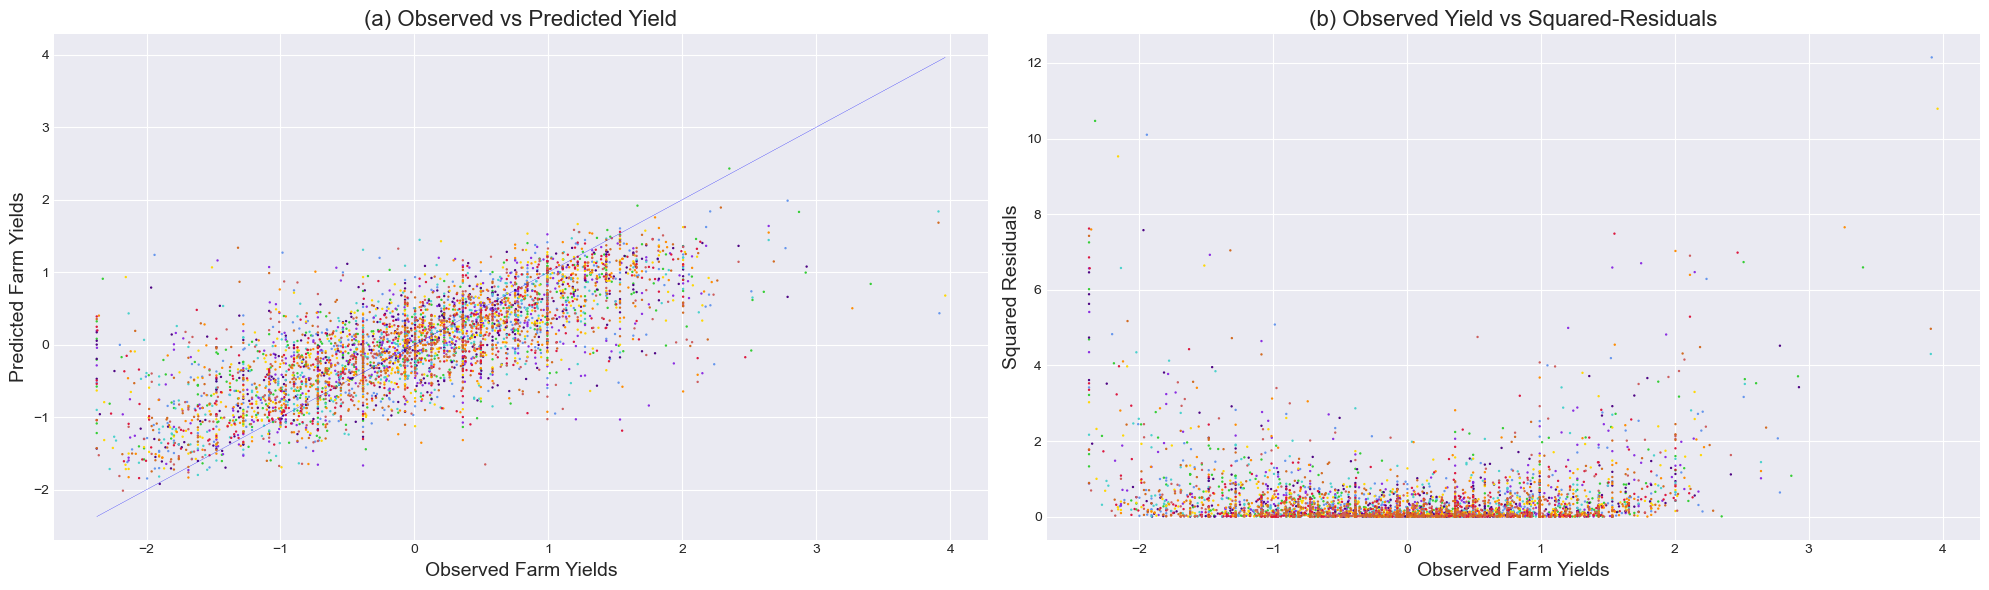

In [107]:
print('The Predictions and Residuals for Rice')
plot_ensemble_predictions(rice_plot_df)

The Predictions and Residuals for Wheat


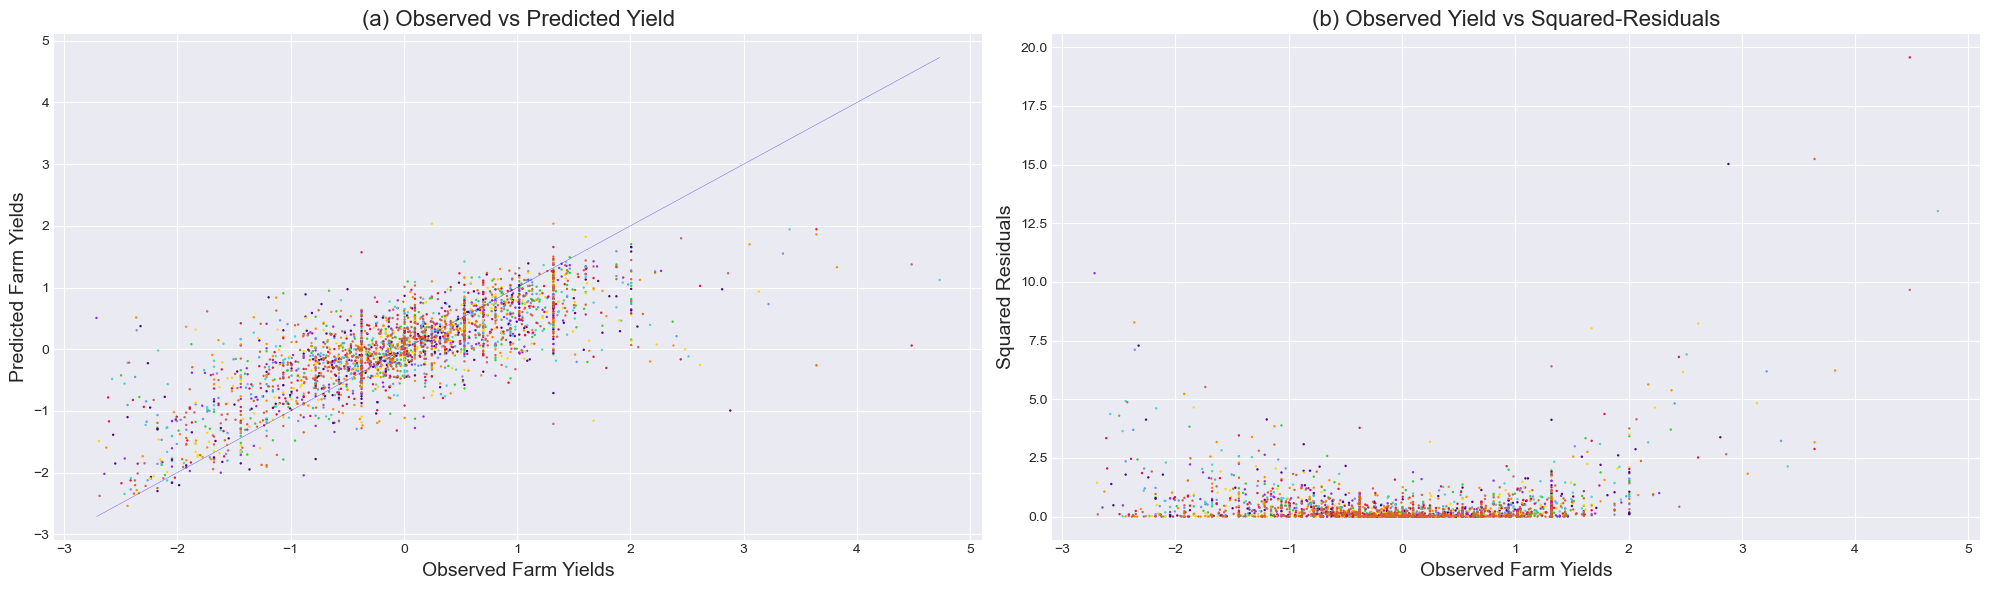

In [108]:
print('The Predictions and Residuals for Wheat')
plot_ensemble_predictions(wheat_plot_df)

## Confidence Bands from the Inter-Quantile bands of XGBoost

Wider inter-quantile bands indicate that the farm has high systemic risk, and a narrower band is a farm that the model has been able to predict with *confidence*. There are two dimensions here - the fold and the farm. The inter-quantile coverage is for the folds - so each fold with the 4400 farms within them and at the fold-level we see the risk-profile of each farm. Therefore, each farm will have 15 risk profiles reported from the folds. The mean of this is the quantile-based risk of each farm.

In [142]:
def plot_coverage(preds,full_conf,up_conf,low_conf,mean_yield,max_band,min_band):

    print(f'Confidence Bands are between {min_band} and {max_band} Standard Deviations')
    coverage_text = f"Coverage = {full_conf}%\nLeft tail = {low_conf}%\nRight tail = {up_conf}%"
    fig,ax=plt.subplots(figsize=(12,5))
    preds=preds.sort_values(by='bands_i',ascending=True).reset_index(drop=True)
    ax.vlines(x=preds['bands_i'],ymin=preds[f'xgb_q{lband}_pred'],ymax=preds[f'xgb_q{uband}_pred'],
              color='skyblue',alpha=0.8,label='XGB Quantile Bands')
    ax.scatter(preds['bands_i'], preds['yeo_farm_crop_yield'], color='crimson', s=2, zorder=2, label='Observed Yield')
    ax.plot(preds['bands_i'],[mean_yield]*preds.shape[0],color='green',alpha=0.3)
    ax.text(
        0.02, 0.02,  # relative position inside the subplot
        coverage_text,
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='bottom',
        horizontalalignment='left',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
        )
    ax.set_ylabel('Observed Farm Yields',fontsize=10)
    ax.set_xlabel('95-5th Percentile Bands normalized by Standard Deviation',fontsize=10)
    plt.suptitle('Farm Yield Prediction Bands',fontsize=13)
    plt.legend()
    plt.show()

In [143]:
random_states=[3504,2992,3529,5042,4053,2492,9193,6843,3923,5935]
def make_quantile_coverage(new_oos,ensemble):
    coverage_list = []
    uband, lband = '95', '05'
    for fold_no in range(1,16):
        cols = ['X_id', f'xgb_q{uband}_pred', f'xgb_q{lband}_pred', 'yeo_farm_crop_yield','xgb_q50_pred']
        preds = new_oos[new_oos['fold'] == fold_no][cols].copy()
        preds = preds.reset_index().rename(columns={'index':'X_id'})
        preds['in_upper'] = (preds['yeo_farm_crop_yield'] <= preds[f'xgb_q{uband}_pred']).astype(int)
        preds['in_lower'] = (preds['yeo_farm_crop_yield'] >= preds[f'xgb_q{lband}_pred']).astype(int)
        preds['full_conf_bool'] = (preds['in_upper'] & preds['in_lower']).astype(int)
        full_conf = np.round(preds['full_conf_bool'].mean() * 100, 2)
        up_conf = np.round(preds['in_upper'].mean() * 100, 2)
        low_conf = np.round(preds['in_lower'].mean() * 100, 2)


    coverage = pd.concat(coverage_list, axis=0).reset_index(drop=True)
    return coverage

### RICE

In [156]:
state_files_path="C://Users/nb/Desktop/paper_2/xgboost_shap/rice_ensemble_random_results/"
ensemble_pred=pd.read_csv(state_files_path+'ensemble_preds_kappa10.csv') ## the index is X_id
ensemble_pred=ensemble_pred.reset_index().rename(columns={'index':'X_id'})
prediction_intervals=[]
for state_space in random_states:
    ensemble_std=ensemble_pred[f'mea_{state_space}'].std()
    uband, lband = '95', '05'
    state_df=pd.read_csv(f'{state_files_path}preds_{state_space}.csv')
    state_df=make_xid(state_df,'rice')
    state_df[f'pred_interval_{state_space}']=(state_df[ f'xgb_q{uband}_pred']-state_df[f'xgb_q{lband}_pred'])/ensemble_std
    prediction_intervals.append(state_df[['X_id',f'pred_interval_{state_space}']].groupby('X_id').mean())

We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True


In [157]:
delta_df=pd.concat(prediction_intervals,axis=1)
high_rice_risk=(delta_df>=delta_df.quantile(0.9)).sum(axis=0)

In [158]:
delta_df.to_csv(f"{drive}/xgboost_shap/rice_ensemble_random_results/pred_delta_rice.csv")

In [14]:
rice_quantiles=[]
for state_space in random_states:
    oos=pd.read_csv(state_files_path+f'preds_{state_space}.csv')
    oos=make_xid(oos,crop='rice')
    ens_df=ensemble_pred[['X_id',f'mea_{state_space}']].rename(columns={f'mea_{state_space}':'y_star'})
    oos_covered=make_quantile_coverage(oos,ens_df)
    oos_covered['state_space']=state_space
    rice_quantiles.append(oos_covered)

,X_id,y_obs,ran_3504,var_3504,mea_3504,ran_2992,var_2992,mea_2992,ran_3529,var_3529,...,mea_9193,ran_6843,var_6843,mea_6843,ran_3923,var_3923,mea_3923,ran_5935,var_5935,mea_5935
0,0,-0.383771,-0.957616,-0.956300,-0.962022,-0.941150,-0.938906,-0.947211,-0.948417,-0.942076,...,-0.959765,-0.922087,-0.924235,-0.943660,-0.925237,-0.926251,-0.933928,-0.941424,-0.942727,-0.954698
1,1,0.582630,-0.321399,-0.308023,-0.201922,-0.314171,-0.309611,-0.187021,-0.337760,-0.347886,...,-0.175461,-0.368996,-0.353626,-0.184524,-0.324728,-0.326155,-0.194971,-0.364912,-0.339414,-0.186545
2,2,1.698389,0.765335,0.767803,0.950001,0.788785,0.777945,0.927682,0.762138,0.750669,...,0.975345,0.755627,0.766275,0.922625,0.880919,0.859343,0.973169,0.780184,0.769021,0.963063
3,3,0.992095,0.792785,0.799143,0.895178,0.808273,0.805148,0.920013,0.738721,0.755461,...,0.922324,0.756199,0.759657,0.917565,0.813853,0.823791,0.931387,0.821727,0.820179,0.910057
4,4,3.405300,0.706229,0.707003,0.837765,0.675422,0.693516,0.806315,0.702759,0.703613,...,0.825097,0.657783,0.651354,0.842174,0.727507,0.732745,0.811184,0.713350,0.719227,0.839359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4435,4435,-0.950454,0.074993,0.070956,0.044377,0.067062,0.067693,0.044260,0.057743,0.058768,...,0.041629,0.061493,0.060624,0.042679,0.076587,0.075687,0.059766,0.089909,0.085903,0.056403
4436,4436,0.843500,-0.222562,-0.221224,-0.176553,-0.181357,-0.177092,-0.133745,-0.176291,-0.184531,...,-0.154670,-0.195599,-0.197685,-0.164509,-0.184001,-0.187372,-0.157076,-0.212714,-0.211867,-0.167111
4437,4437,1.462777,1.292832,1.291409,1.326240,1.273020,1.275704,1.322704,1.272183,1.278179,...,1.313031,1.299477,1.294386,1.322123,1.278406,1.280054,1.321653,1.264366,1.264935,1.315732
4438,4438,1.534198,0.460821,0.469452,0.512346,0.457000,0.468211,0.512567,0.451842,0.459686,...,0.533254,0.454325,0.460278,0.514724,0.451424,0.454555,0.522734,0.470264,0.472861,0.510300


In [11]:
rice_quantiles_df=pd.concat(rice_quantiles,axis=0)
coverage=np.round(rice_quantiles_df[['state_space','fold_no','fold_conf','fold_uconf','fold_lconf']],2).groupby(['state_space','fold_no']).mean().reset_index()
print('There should be 150 rows = ',coverage.shape[0])
state_coverage=np.round(coverage[['state_space','fold_conf','fold_uconf','fold_lconf']].groupby('state_space').mean(),2)
print(state_coverage)
print('Average Coverage across State-Spaces')
print(np.round(state_coverage.mean(axis=0)),2)

There should be 150 rows =  150
             fold_conf  fold_uconf  fold_lconf
state_space                                   
2492             86.89       93.21       93.69
2992             86.93       93.19       93.74
3504             86.96       93.22       93.75
3529             87.02       93.23       93.80
3923             86.94       93.21       93.73
4053             86.95       93.21       93.75
5042             86.89       93.20       93.70
5935             86.90       93.21       93.69
6843             86.92       93.19       93.73
9193             86.93       93.20       93.73
Average Coverage across State-Spaces
fold_conf     87.0
fold_uconf    93.0
fold_lconf    94.0
dtype: float64 2


### WHEAT

In [159]:
state_files_path=f"{drive}/xgboost_shap/wheat_ensemble_random_results/"
ensemble_pred=pd.read_csv(state_files_path+'ensemble_preds_kappa10.csv') ## the index is X_id
ensemble_pred=ensemble_pred.reset_index().rename(columns={'index':'X_id'})
prediction_intervals=[]
for state_space in random_states:
    ensemble_std=ensemble_pred[f'mea_{state_space}'].std()
    uband, lband = '95', '05'
    state_df=pd.read_csv(f'{state_files_path}preds_{state_space}.csv')
    state_df=make_xid(state_df,'wheat')
    state_df[f'pred_interval_{state_space}']=(state_df[ f'xgb_q{uband}_pred']-state_df[f'xgb_q{lband}_pred'])/ensemble_std
    prediction_intervals.append(state_df[['X_id',f'pred_interval_{state_space}']].groupby('X_id').mean())

We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True


In [160]:
delta_df=pd.concat(prediction_intervals,axis=1)
high_wheat_risk=(delta_df>=delta_df.quantile(0.9)).sum(axis=0)

In [161]:
delta_df.to_csv(f"{drive}/xgboost_shap/wheat_ensemble_random_results/pred_delta_wheat.csv")

In [47]:
wheat_quantiles=[]
for state_space in random_states:
    oos=pd.read_csv(state_files_path+f'preds_{state_space}.csv')
    oos=make_xid(oos,crop='wheat')
    ens_df=ensemble_pred[['X_id',f'mea_{state_space}']].rename(columns={f'mea_{state_space}':'y_star'})
    oos_covered=make_quantile_coverage(oos,ens_df)
    oos_covered['state_space']=state_space
    wheat_quantiles.append(oos_covered)

We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True
We have unique X-row identifiers :  True


In [48]:
wheat_quantiles_df=pd.concat(wheat_quantiles,axis=0)
coverage=np.round(wheat_quantiles_df[['state_space','fold_no','fold_conf','fold_uconf','fold_lconf']],2).groupby(['state_space','fold_no']).mean().reset_index()
print('There should be 150 rows = ',coverage.shape[0])
state_coverage=np.round(coverage[['state_space','fold_conf','fold_uconf','fold_lconf']].groupby('state_space').mean(),2)
print(state_coverage)
print('Average Coverage across State-Spaces')
print(np.round(state_coverage.mean(axis=0)),2)

There should be 150 rows =  150
             fold_conf  fold_uconf  fold_lconf
state_space                                   
2492             88.19       93.71       94.48
2992             88.15       93.71       94.44
3504             88.25       93.79       94.47
3529             88.14       93.71       94.44
3923             88.10       93.68       94.43
4053             88.10       93.64       94.46
5042             88.17       93.71       94.45
5935             88.21       93.80       94.41
6843             88.08       93.69       94.39
9193             88.09       93.65       94.44
Average Coverage across State-Spaces
fold_conf     88.0
fold_uconf    94.0
fold_lconf    94.0
dtype: float64 2


## Shapley

In [75]:
def make_xgb_shapley(insample_df,dep_var):
        
        inX,inY=insample_df.copy().drop(dep_var,axis=1),insample_df[dep_var]
        model = XGBRegressor(objective="reg:pseudohubererror",learning_rate= 0.05,
                             n_estimators= 1000,max_depth= 6,min_child_weight= 6,                  
                             subsample= 0.7,colsample_bytree= 0.7,reg_lambda= 2.5,
                             reg_alpha= 2,gamma= 0.7)
        model.fit(inX,inY)
        y_hat = model.predict(inX)

        print(f"RMSE: {mean_squared_error(inY, y_hat, squared=False):.4f}")
        print(f"MAE : {mean_absolute_error(inY, y_hat,):.4f}")
        print(f"R²  : {r2_score(inY, y_hat,):.4f}")

        explainer = shap.TreeExplainer(model)
        shap_values = explainer(inX).values
        shap_df=pd.DataFrame(shap_values,columns=[f'shap_{i}' for i in inX.columns])
        shap_df=pd.concat([shap_df,inY],axis=1)
        return shap_df

In [128]:
def plot_shapley(shap_df):
    feature_names={'shap_yeo_farm_land_m2':'Farm Size ($m^2$)', 
               'shap_yeo_share_own_and_possessed':'Land Ownership Share', 
               'shap_yeo_cost_energy_pm2':'Energy Cost (p$m^2$)',
               'shap_yeo_cost_labour_pm2':'Labour Cost (p$m^2$)', 
               'shap_yeo_cost_finance_pm2':'Finance Cost (p$m^2$)',
               'shap_yeo_cost_fert_pm2':'Fertilizer Cost (p$m^2$)',
               'shap_yeo_cost_pest_pm2':'Pesticide Cost (p$m^2$)',
               'shap_yeo_cost_machine_pm2':'Machine Cost (p$m^2$)', 
               'shap_yeo_cost_irrigation_pm2':'Irrigation Cost (p$m^2$)', 
               'shap_yeo_cost_seeds_pm2':'Seeds Cost (p$m^2$)',
               'shap_yeo_hh_cons_exp_pm_pm2':'Hhld. Cons. Exp. (per month and p$m^2$)',
               'shap_yeo_median_speiSPEI-4MO':'SPEI (median)', 
               'shap_yeo_max_speiSPEI-4MO':'SPEI (max)',
               'shap_yeo_min_speiSPEI-4MO':'SPEI (min)', 
               'shap_yeo_std_speiSPEI-4MO':'SPEI (std)',
               'shap_yeo_tp_mean':'Precipitation (mean)',
               'shap_yeo_tp_std':'Precipitation (std)', 
               'shap_ln_t2m_mean':'Surface Temperature (mean)',
               'shap_yeo_t2m_max':'Surface Temperature (max)', 
               'shap_yeo_t2m_min':'Surface Temperature (min)', 
               'shap_yeo_t2m_std':'Surface Temperature (std)', 
               'shap_yeo_slhf_mean':'Surface Heat Flux (mean)', 
               'shap_yeo_slhf_max':'Surface Heat Flux (max)', 
               'shap_yeo_slhf_std':'Surface Heat Flux (std)', 
               'shap_yeo_ssr_mean':'Solar Radiation (mean)', 
               'shap_ln_ssr_max':'Solar Radiation (max)', 
               'shap_ln_ssr_min':'Solar Radiation (min)', 
               'shap_yeo_ssr_std':'Solar Radiation (std)', 
               'shap_if_land_irrigated':'If Land Irrigated', 
               'shap_is_non_backward_caste':'Not-Backward Caste',
               'shap_if_farmer_organisation':'Farmer Organisation', 
               'shap_if_kisan_credit_card':'Access to Farmer Credit', 
               'shap_if_soil_health_card':'Soil Health Card',
               'shap_primary_irrigation_canal':'Irrigation Type: Canal',
               'shap_primary_irrigation_gw':'Irrigation Type: GW', 
               'shap_primary_irrigation_mixed':'Irrigation Type: Mixed',
               'shap_primary_irrigation_msw':'Irrigation Type: Surface', 
               'shap_primary_irrigation_others':'Irrigation Type: Others'}
    abs_shap = ( shap_df.drop('yeo_farm_crop_yield', axis=1).abs().mean(axis=0).sort_values(ascending=False))

    top_features = abs_shap[abs_shap > abs_shap.quantile(0.79)].index.tolist()

    mean_shap = abs_shap.loc[top_features]
    violin_shap = rice_shap[top_features]

    x_pos = np.arange(len(top_features))

    fig, ax_left = plt.subplots(figsize=(12, 8))

    # ---- LEFT AXIS: violin plots ----
    vp = ax_left.violinplot(
        violin_shap.values,
        positions=x_pos,
        widths=0.7,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    ax_left.set_ylabel("SHAP value")
    ax_left.set_xticks(x_pos)
    
    top_features_labels=[feature_names[i] for i in top_features]
    ax_left.set_xticklabels(top_features_labels, rotation=45, ha='right')
    # ---- RIGHT AXIS: mean |SHAP| ----
    ax_right = ax_left.twinx()

    ax_right.plot(
        x_pos,
        mean_shap.values,
        marker='o',
        linewidth=2
    )

    ax_right.set_ylabel("Mean |SHAP value|")

    # ---- Aesthetics ----
    #ax_left.set_title("Feature Importance: Distribution and Mean Absolute SHAP")
    ax_left.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

### RICE

In [63]:
path=f"{drive}/xgboost_shap/feature_engineering/"
insample=pd.read_csv(path+'shared_yeoinsample_rice_vJan.csv')
finalcols=['yeo_farm_crop_yield', 'yeo_farm_land_m2', 'yeo_share_own_and_possessed', 'yeo_cost_energy_pm2',
           'yeo_cost_labour_pm2', 'yeo_cost_finance_pm2','yeo_cost_fert_pm2','yeo_cost_pest_pm2',
           'yeo_cost_machine_pm2', 'yeo_cost_irrigation_pm2', 'yeo_cost_seeds_pm2','yeo_hh_cons_exp_pm_pm2',
           'yeo_median_speiSPEI-4MO', 'yeo_max_speiSPEI-4MO','yeo_min_speiSPEI-4MO', 'yeo_std_speiSPEI-4MO',
           'yeo_tp_mean','yeo_tp_std', 'ln_t2m_mean','yeo_t2m_max', 'yeo_t2m_min', 'yeo_t2m_std', 
           'yeo_slhf_mean', 'yeo_slhf_max', 'yeo_slhf_std', 'yeo_ssr_mean', 
           'ln_ssr_max', 'ln_ssr_min', 'yeo_ssr_std']
states=    ['state_10','state_11', 'state_12', 'state_13', 'state_14', 'state_15', 'state_16',
            'state_17', 'state_18', 'state_19', 'state_2', 'state_20', 'state_21',
            'state_22', 'state_23', 'state_24', 'state_25', 'state_26', 'state_27',
            'state_28', 'state_29', 'state_3', 'state_30', 'state_32', 'state_33',
            'state_34', 'state_36', 'state_4', 'state_5', 'state_6', 'state_7','state_8', 'state_9']
dummies=   [ 'if_land_irrigated', 'is_non_backward_caste','if_farmer_organisation', 
             'if_kisan_credit_card', 'if_soil_health_card','primary_irrigation_canal',
             'primary_irrigation_gw', 'primary_irrigation_mixed',
             'primary_irrigation_msw', 'primary_irrigation_others']
insample = insample[finalcols+dummies+states]
insample[states]=insample[states].astype(int)
rice_shap=make_xgb_shapley(insample,dep_var='yeo_farm_crop_yield')

RMSE: 0.5263
MAE : 0.3834
R²  : 0.7230


The SHAPLEY for RICE


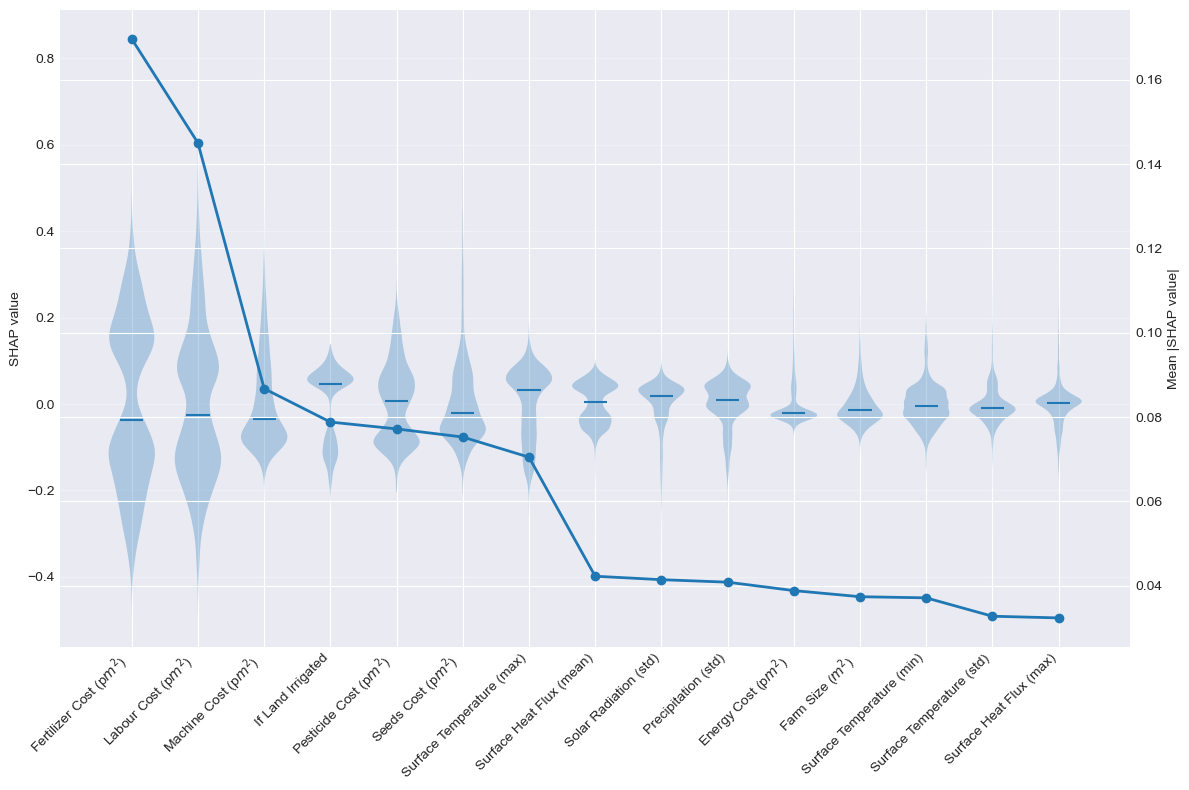

In [130]:
print('The SHAPLEY for RICE')
plot_shapley(rice_shap)

### WHEAT

In [131]:
path=f"{drive}/xgboost_shap/feature_engineering/"
insample=pd.read_csv(path+'shared_yeoinsample_wheat_vJan.csv')
finalcols=['yeo_farm_crop_yield', 'yeo_farm_land_m2', 'yeo_share_own_and_possessed',
            'yeo_cost_energy_pm2','yeo_cost_labour_pm2', 'yeo_cost_finance_pm2', 'yeo_cost_fert_pm2','yeo_cost_pest_pm2',
            'yeo_cost_machine_pm2', 'yeo_cost_irrigation_pm2', 'yeo_cost_seeds_pm2','yeo_hh_cons_exp_pm_pm2',
            'yeo_median_speiSPEI-4MO', 'yeo_max_speiSPEI-4MO','yeo_min_speiSPEI-4MO', 'yeo_std_speiSPEI-4MO',
             'yeo_tp_mean','yeo_tp_std', 'ln_t2m_mean', 'yeo_t2m_max', 'yeo_t2m_min',
       'yeo_t2m_std', 'yeo_slhf_mean', 'yeo_slhf_max', 'yeo_slhf_std',
       'yeo_ssr_mean', 'ln_ssr_max', 'ln_ssr_min', 'yeo_ssr_std',]
states=    ['state_10','state_11', 'state_12', 'state_13', 'state_14', 'state_15', 'state_16',
            'state_17', 'state_18', 'state_19', 'state_2', 'state_20', 'state_21',
            'state_22', 'state_23', 'state_24', 'state_25', 'state_26', 'state_27',
            'state_28', 'state_29', 'state_3', 'state_30', 'state_32', 'state_33',
            'state_34', 'state_36', 'state_4', 'state_5', 'state_6', 'state_7','state_8', 'state_9']
dummies=   [ 'if_land_irrigated', 'is_non_backward_caste','if_farmer_organisation', 
             'if_kisan_credit_card', 'if_soil_health_card','primary_irrigation_canal',
             'primary_irrigation_gw', 'primary_irrigation_mixed',
             'primary_irrigation_msw', 'primary_irrigation_others']
insample = insample[finalcols+dummies+states]
insample[states]=insample[states].astype(int)
wheat_shap=make_xgb_shapley(insample,dep_var='yeo_farm_crop_yield')

RMSE: 0.5275
MAE : 0.3717
R²  : 0.7217


The SHAPLEY for WHEAT


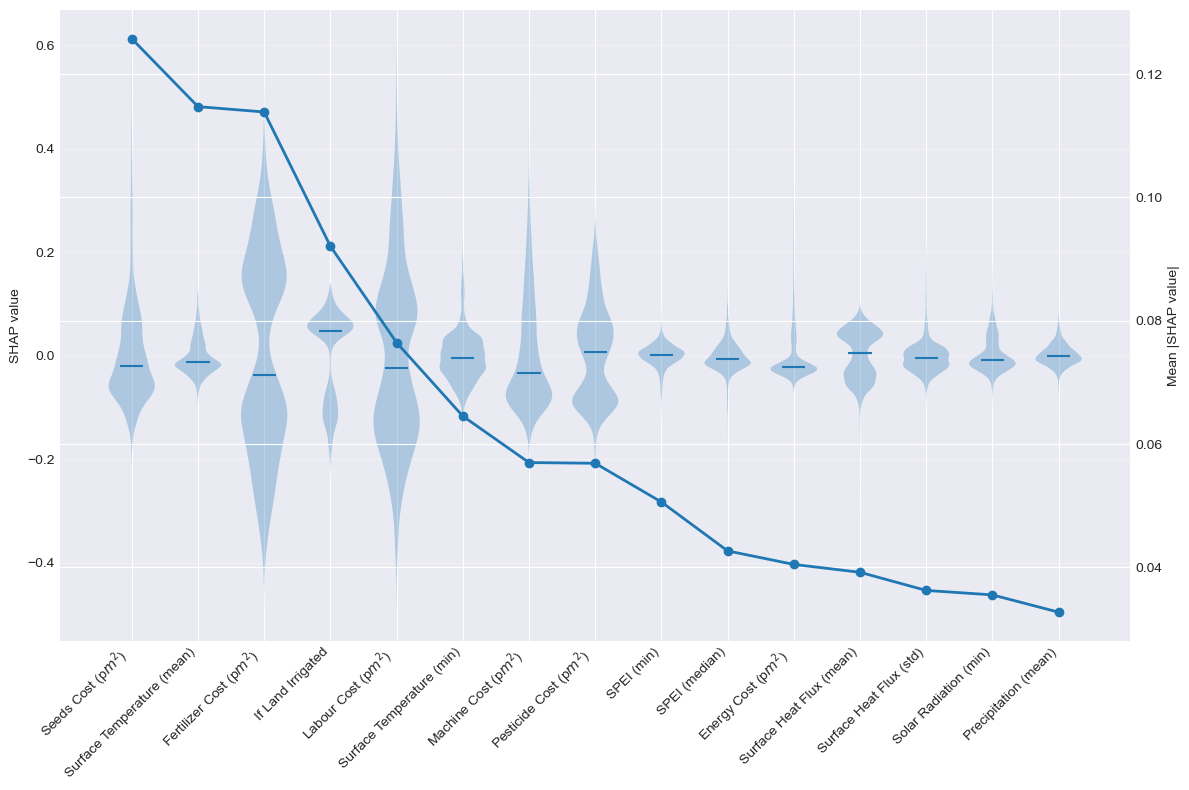

In [132]:
print('The SHAPLEY for WHEAT')
plot_shapley(wheat_shap)

## Map of $R^2$ and Risk

In [3]:
import geopandas as gpd
shpfile=gpd.read_file(f"{drive}/shapefile/DISTRICT_BOUNDARY.shp")
shpfile=shpfile[['ID','geometry']].rename(columns={'ID':'spei_district_code'})
print('The Number of districts in the shapefile = ',shpfile.shape[0])

The Number of districts in the shapefile =  742


In [65]:
## BONUS: mapping rice farms to yields (1)
oosrice_district_map=pd.read_csv(f"{drive}/xgboost_shap/feature_engineering/oosrice_district_map.csv")
num_t2m_mean_map=oosrice_district_map.t2m_mean_rank.nunique()
print('The NSS-CODE and DISTRICT-CODE with T2M_MEAN RANKS')
print(oosrice_district_map.describe())
print()

The NSS-CODE and DISTRICT-CODE with T2M_MEAN RANKS
       t2m_mean_rank  nss_district_code19    t2m_mean  spei_district_code
count     474.000000           474.000000  474.000000          474.000000
mean      236.500000          1748.381857  297.041307          379.786920
std       136.976275           939.882193    3.760567          214.333785
min         0.000000           102.000000  273.951228            3.000000
25%       118.250000           961.250000  296.849615          194.250000
50%       236.500000          1820.500000  297.939634          381.000000
75%       354.750000          2329.500000  298.688922          564.750000
max       473.000000          3631.000000  301.968284          741.000000



In [68]:
## BONUS: mapping rice farms to yields (2)
## OOS is the same farms, so we take one of the state-spaces and track the X_id to district ID
oos_xid=pd.read_csv(f"{drive}/xgboost_shap/rice_ensemble_random_results/preds_3504.csv")
oos_xid=make_xid(oos_xid,'rice') ## 15 folds for each X_id is confirmed
oos_xid=oos_xid[['X_id','ln_t2m_mean']]
oos_xid=oos_xid.drop_duplicates()
num_unique=oos_xid.ln_t2m_mean.nunique()
print('The number of unique ln_t2m_mean values = ',num_unique)
print('The number of unique t2m_mean values in the map data = ',num_t2m_mean_map)
if num_unique==num_t2m_mean_map:
    print('The number of t2m values equals the number of districts, therefore we can do a mapping')
else:
    print('no')

We have unique X-row identifiers :  True
The number of unique ln_t2m_mean values =  474
The number of unique t2m_mean values in the map data =  474
The number of t2m values equals the number of districts, therefore we can do a mapping


In [70]:
## BONUS: mapping rice farms to yields (3)
oos_xid=oos_xid[['X_id','ln_t2m_mean']].reset_index(drop=True).sort_values(by='ln_t2m_mean').reset_index(drop=True)
oos_xid['t2m_mean_rank']=oos_xid.groupby('ln_t2m_mean').ngroup()
oos_xid

,X_id,ln_t2m_mean,t2m_mean_rank
0,390,5.612950,0
1,1111,5.612950,0
2,201,5.618077,1
3,671,5.618077,1
4,757,5.618571,2
...,...,...,...
4435,4393,5.710322,473
4436,4114,5.710322,473
4437,1864,5.710322,473
4438,2471,5.710322,473


In [71]:
## BONUS: mapping rice farms to yields (4)
print('Merging on the ln_t2m_mean and t2m_mean ranks since log is monotonic transformation')
final_oosrice_map=pd.merge(oosrice_district_map[['spei_district_code','t2m_mean_rank']],
                           oos_xid[['X_id','t2m_mean_rank']],
                           on='t2m_mean_rank')
print(final_oosrice_map.head())
print()
print(final_oosrice_map.describe())
print()
print('VERY IMPORTANT - SAVING THE OOS X_id-to-spei_district_code MAP') 
print('The number of X_id = ',final_oosrice_map.X_id.nunique())
print('The number of OOS rice districts = ',final_oosrice_map.t2m_mean_rank.nunique())
final_oosrice_map.to_csv(f"{drive}/xgboost_shap/feature_engineering/oosrice_district_xid_map.csv",index=False)
print('The rice-district-xid map is saved!')

Merging on the ln_t2m_mean and t2m_mean ranks since log is monotonic transformation
   spei_district_code  t2m_mean_rank  X_id
0                 413            468  3980
1                 413            468  2892
2                 413            468  1920
3                 413            468  3022
4                 413            468  1815

       spei_district_code  t2m_mean_rank         X_id
count         4440.000000    4440.000000  4440.000000
mean           380.589865     275.283784  2219.500000
std            221.800296     126.214311  1281.861927
min              3.000000       0.000000     0.000000
25%            171.000000     174.000000  1109.750000
50%            375.000000     299.000000  2219.500000
75%            578.250000     381.000000  3329.250000
max            741.000000     473.000000  4439.000000

VERY IMPORTANT - SAVING THE OOS X_id-to-spei_district_code MAP
The number of X_id =  4440
The number of OOS rice districts =  474
The rice-district-xid map is saved!


In [74]:
## BONUS: mapping wheat farms to yields (1)
ooswheat_district_map=pd.read_csv(f"{drive}/xgboost_shap/feature_engineering/ooswheat_district_map.csv")
num_t2m_mean_map=ooswheat_district_map.t2m_mean_rank.nunique()
print('The NSS-CODE and DISTRICT-CODE with T2M_MEAN RANKS')
print(ooswheat_district_map.describe())
print()

The NSS-CODE and DISTRICT-CODE with T2M_MEAN RANKS
       t2m_mean_rank  nss_district_code19    t2m_mean  spei_district_code
count     309.000000           309.000000  309.000000          309.000000
mean      154.000000          1242.378641  297.533011          309.297735
std        89.344838           779.064713    4.750332          181.923816
min         0.000000           105.000000  267.757624            2.000000
25%        77.000000           806.000000  297.487533          153.000000
50%       154.000000           951.000000  298.632737          311.000000
75%       231.000000          2223.000000  299.575082          479.000000
max       308.000000          2731.000000  303.247717          614.000000



In [75]:
## BONUS: mapping wheat farms to yields (2)
## OOS is the same farms, so we take one of the state-spaces and track the X_id to district ID
oos_xid=pd.read_csv(f"{drive}/xgboost_shap/wheat_ensemble_random_results/preds_3504.csv")
oos_xid=make_xid(oos_xid,'wheat') ## 15 folds for each X_id is confirmed
oos_xid=oos_xid[['X_id','ln_t2m_mean']]
oos_xid=oos_xid.drop_duplicates()
num_unique=oos_xid.ln_t2m_mean.nunique()
print('The number of unique ln_t2m_mean values = ',num_unique)
print('The number of unique t2m_mean values in the map data = ',num_t2m_mean_map)
if num_unique==num_t2m_mean_map:
    print('The number of t2m values equals the number of districts, therefore we can do a mapping')
else:
    print('no')

We have unique X-row identifiers :  True
The number of unique ln_t2m_mean values =  309
The number of unique t2m_mean values in the map data =  309
The number of t2m values equals the number of districts, therefore we can do a mapping


In [76]:
## BONUS: mapping wheat farms to yields (3)
oos_xid=oos_xid[['X_id','ln_t2m_mean']].reset_index(drop=True).sort_values(by='ln_t2m_mean').reset_index(drop=True)
oos_xid['t2m_mean_rank']=oos_xid.groupby('ln_t2m_mean').ngroup()
oos_xid

,X_id,ln_t2m_mean,t2m_mean_rank
0,1513,5.590082,0
1,1115,5.590082,0
2,754,5.590082,0
3,1099,5.590082,0
4,1591,5.598845,1
...,...,...,...
2699,1857,5.713131,307
2700,2631,5.713131,307
2701,1167,5.713131,307
2702,2436,5.713131,307


In [77]:
## BONUS: mapping wheat farms to yields (3)
print('Merging on the ln_t2m_mean and t2m_mean ranks since log is monotonic transformation')
final_ooswheat_map=pd.merge(ooswheat_district_map[['spei_district_code','t2m_mean_rank']],
                           oos_xid[['X_id','t2m_mean_rank']],
                           on='t2m_mean_rank')
print(final_ooswheat_map.head())
print()
print(final_ooswheat_map.describe())
print()
print('VERY IMPORTANT - SAVING THE OOS X_id-to-spei_district_code MAP') 
print('The number of X_id = ',final_ooswheat_map.X_id.nunique())
print('The number of OOS wheat districts = ',final_ooswheat_map.t2m_mean_rank.nunique())
final_ooswheat_map.to_csv(f"{drive}/xgboost_shap/feature_engineering/ooswheat_district_xid_map.csv",index=False)
print('The wheat-district-xid map is saved!')

Merging on the ln_t2m_mean and t2m_mean ranks since log is monotonic transformation
   spei_district_code  t2m_mean_rank  X_id
0                 425            226  1006
1                 425            226  2288
2                 425            226   942
3                 425            226   990
4                 425            226  2330

       spei_district_code  t2m_mean_rank         X_id
count         2704.000000    2704.000000  2704.000000
mean           308.892012     155.729290  1351.500000
std            182.041864      76.655139   780.721888
min              2.000000       0.000000     0.000000
25%            152.000000      96.000000   675.750000
50%            314.000000     159.500000  1351.500000
75%            472.000000     213.000000  2027.250000
max            614.000000     308.000000  2703.000000

VERY IMPORTANT - SAVING THE OOS X_id-to-spei_district_code MAP
The number of X_id =  2704
The number of OOS wheat districts =  309
The wheat-district-xid map is saved!


### RICE

In [134]:
final_oosrice_map=pd.read_csv(f"{drive}/xgboost_shap/feature_engineering/oosrice_district_xid_map.csv")
ensemble_r2=pd.read_csv("C://Users/nb/Desktop/paper_2/xgboost_shap/rice_ensemble_random_results/ensemble_preds_kappa10.csv")
ensemble_r2['y_star']=ensemble_r2[['mea_3504', 'mea_2992', 'mea_3529', 'mea_5042', 
             'mea_4053', 'mea_2492', 'mea_9193', 'mea_6843', 
             'mea_3923', 'mea_5935']].mean(axis=1)
ensemble_r2=ensemble_r2[['y_obs','y_star']]
ensemble_r2=pd.concat([final_oosrice_map.set_index('X_id'),
                      ensemble_r2],axis=1).drop('t2m_mean_rank',axis=1)
ensemble_r2

,spei_district_code,y_obs,y_star
3980,413,-0.185208,0.576103
2892,413,-1.478212,-0.100256
1920,413,0.843500,0.968047
3022,413,1.824456,0.610503
1815,413,0.361032,0.699623
...,...,...,...
3244,266,0.670774,0.213175
1226,266,-0.969299,0.165680
3366,266,-0.461806,-0.132844
995,266,0.126880,0.256268


In [135]:
r2_by_district = (ensemble_r2.assign(district_size=lambda df: df.groupby('spei_district_code')['y_obs'].transform('count'))
        .query('district_size >= 5')
        .groupby(['spei_district_code','district_size'])
        .apply(lambda g: r2_score(g['y_obs'], g['y_star']), include_groups=False)
        .reset_index(name='r2')
)
r2_by_district['r2_norm']=r2_by_district['r2']/r2_by_district['district_size']
r2_by_district['r2_rank']=r2_by_district['r2_norm'].rank(ascending=False)

In [137]:
r2_by_district

,spei_district_code,district_size,r2,r2_norm,r2_rank
0,11,5,-2.317546,-0.463509,318.0
1,16,37,-0.048742,-0.001317,199.0
2,17,11,-0.138213,-0.012565,229.0
3,18,26,-0.119808,-0.004608,210.0
4,25,7,-1.002074,-0.143153,294.0
...,...,...,...,...,...
317,731,8,0.235638,0.029455,89.0
318,732,17,-0.151736,-0.008926,221.0
319,734,7,-1.487745,-0.212535,307.0
320,738,5,0.002486,0.000497,188.0


In [178]:
rice_delta=pd.read_csv(f"{drive}/xgboost_shap/rice_ensemble_random_results/pred_delta_rice.csv")
rice_delta=pd.concat([final_oosrice_map.set_index('X_id'),
                      rice_delta.set_index('X_id')],axis=1).drop('t2m_mean_rank',axis=1)
rice_delta['pred_interval']=rice_delta[[f'pred_interval_{i}' for i in random_states]].mean(axis=1)
rice_delta=rice_delta[['spei_district_code','pred_interval']].groupby('spei_district_code').mean()

In [181]:
rice_map_data=pd.concat([rice_delta,r2_by_district.set_index('spei_district_code')],axis=1,join='outer')
rice_map_data.to_csv(f"{drive}/xgboost_shap/rice_ensemble_random_results/rice_map_data.csv")

In [134]:
ensemble_r2=pd.read_csv(f"{drive}/xgboost_shap/rice_ensemble_random_results/ensemble_preds_kappa10.csv")
ensemble_r2['y_star']=ensemble_r2[['mea_3504', 'mea_2992', 'mea_3529', 'mea_5042', 
             'mea_4053', 'mea_2492', 'mea_9193', 'mea_6843', 
             'mea_3923', 'mea_5935']].mean(axis=1)
ensemble_r2=ensemble_r2[['y_obs','y_star']]
ensemble_r2=pd.concat([final_oosrice_map.set_index('X_id'),
                      ensemble_r2],axis=1).drop('t2m_mean_rank',axis=1)
ensemble_r2

,spei_district_code,y_obs,y_star
3980,413,-0.185208,0.576103
2892,413,-1.478212,-0.100256
1920,413,0.843500,0.968047
3022,413,1.824456,0.610503
1815,413,0.361032,0.699623
...,...,...,...
3244,266,0.670774,0.213175
1226,266,-0.969299,0.165680
3366,266,-0.461806,-0.132844
995,266,0.126880,0.256268


In [135]:
r2_by_district = (ensemble_r2.assign(district_size=lambda df: df.groupby('spei_district_code')['y_obs'].transform('count'))
        .query('district_size >= 5')
        .groupby(['spei_district_code','district_size'])
        .apply(lambda g: r2_score(g['y_obs'], g['y_star']), include_groups=False)
        .reset_index(name='r2')
)
r2_by_district['r2_norm']=r2_by_district['r2']/r2_by_district['district_size']
r2_by_district['r2_rank']=r2_by_district['r2_norm'].rank(ascending=False)

In [137]:
r2_by_district

,spei_district_code,district_size,r2,r2_norm,r2_rank
0,11,5,-2.317546,-0.463509,318.0
1,16,37,-0.048742,-0.001317,199.0
2,17,11,-0.138213,-0.012565,229.0
3,18,26,-0.119808,-0.004608,210.0
4,25,7,-1.002074,-0.143153,294.0
...,...,...,...,...,...
317,731,8,0.235638,0.029455,89.0
318,732,17,-0.151736,-0.008926,221.0
319,734,7,-1.487745,-0.212535,307.0
320,738,5,0.002486,0.000497,188.0


In [178]:
rice_delta=pd.read_csv("C://Users/nb/Desktop/paper_2/xgboost_shap/rice_ensemble_random_results/pred_delta_rice.csv")
rice_delta=pd.concat([final_oosrice_map.set_index('X_id'),
                      rice_delta.set_index('X_id')],axis=1).drop('t2m_mean_rank',axis=1)
rice_delta['pred_interval']=rice_delta[[f'pred_interval_{i}' for i in random_states]].mean(axis=1)
rice_delta=rice_delta[['spei_district_code','pred_interval']].groupby('spei_district_code').mean()

In [181]:
rice_map_data=pd.concat([rice_delta,r2_by_district.set_index('spei_district_code')],axis=1,join='outer')
rice_map_data.to_csv("C://Users/nb/Desktop/paper_2/xgboost_shap/rice_ensemble_random_results/rice_map_data.csv")

### WHEAT

In [27]:
final_ooswheat_map=pd.read_csv(f"{drive}/xgboost_shap/feature_engineering/ooswheat_district_xid_map.csv")
ensemble_r2=pd.read_csv(f"{drive}/xgboost_shap/wheat_ensemble_random_results/ensemble_preds_kappa10.csv")
ensemble_r2['y_star']=ensemble_r2[['mea_3504', 'mea_2992', 'mea_3529', 'mea_5042', 
             'mea_4053', 'mea_2492', 'mea_9193', 'mea_6843', 
             'mea_3923', 'mea_5935']].mean(axis=1)
ensemble_r2=ensemble_r2[['y_obs','y_star']]
ensemble_r2=pd.concat([final_ooswheat_map.set_index('X_id'),
                      ensemble_r2],axis=1).drop('t2m_mean_rank',axis=1)
ensemble_r2

,spei_district_code,y_obs,y_star
1006,425,-0.125819,0.146097
2288,425,0.112329,0.161977
942,425,-0.825584,0.288762
990,425,-0.025439,0.339734
2330,425,-0.815406,0.097698
...,...,...,...
932,469,0.427165,-0.312403
2089,469,0.006331,-0.095412
2282,469,-0.405968,-0.277339
692,469,0.062735,0.685721


In [28]:
r2_by_district = (ensemble_r2.assign(district_size=lambda df: df.groupby('spei_district_code')['y_obs'].transform('count'))
        .query('district_size >= 5')
        .groupby(['spei_district_code','district_size'])
        .apply(lambda g: r2_score(g['y_obs'], g['y_star']), include_groups=False)
        .reset_index(name='r2')
)
r2_by_district['r2_norm']=r2_by_district['r2']/r2_by_district['district_size']
r2_by_district['r2_rank']=r2_by_district['r2_norm'].rank(ascending=False)

In [29]:
r2_by_district

,spei_district_code,district_size,r2,r2_norm,r2_rank
0,2,22,0.502171,0.022826,76.0
1,3,5,-356.869454,-71.373891,218.0
2,5,17,-0.017332,-0.001020,146.0
3,14,12,0.264611,0.022051,82.0
4,17,22,-0.159415,-0.007246,158.0
...,...,...,...,...,...
213,591,9,-0.214613,-0.023846,173.0
214,593,7,0.307080,0.043869,49.0
215,596,8,0.449310,0.056164,36.0
216,598,6,-2.358675,-0.393112,208.0


In [30]:
wheat_delta=pd.read_csv(f"{drive}/xgboost_shap/wheat_ensemble_random_results/pred_delta_wheat.csv")
wheat_delta=pd.concat([final_ooswheat_map.set_index('X_id'),
                      wheat_delta.set_index('X_id')],axis=1).drop('t2m_mean_rank',axis=1)
wheat_delta['pred_interval']=wheat_delta[[f'pred_interval_{i}' for i in random_states]].mean(axis=1)
wheat_delta=wheat_delta[['spei_district_code','pred_interval']].groupby('spei_district_code').mean()

In [31]:
wheat_map_data=pd.concat([wheat_delta,r2_by_district.set_index('spei_district_code')],axis=1,join='outer')
wheat_map_data.to_csv(f"{drive}/xgboost_shap/wheat_ensemble_random_results/wheat_map_data.csv")

In [32]:
ensemble_r2=pd.read_csv(f"{drive}/xgboost_shap/wheat_ensemble_random_results/ensemble_preds_kappa10.csv")
ensemble_r2['y_star']=ensemble_r2[['mea_3504', 'mea_2992', 'mea_3529', 'mea_5042', 
             'mea_4053', 'mea_2492', 'mea_9193', 'mea_6843', 
             'mea_3923', 'mea_5935']].mean(axis=1)
ensemble_r2=ensemble_r2[['y_obs','y_star']]
ensemble_r2=pd.concat([final_ooswheat_map.set_index('X_id'),
                      ensemble_r2],axis=1).drop('t2m_mean_rank',axis=1)
ensemble_r2

,spei_district_code,y_obs,y_star
1006,425,-0.125819,0.146097
2288,425,0.112329,0.161977
942,425,-0.825584,0.288762
990,425,-0.025439,0.339734
2330,425,-0.815406,0.097698
...,...,...,...
932,469,0.427165,-0.312403
2089,469,0.006331,-0.095412
2282,469,-0.405968,-0.277339
692,469,0.062735,0.685721


In [33]:
r2_by_district = (ensemble_r2.assign(district_size=lambda df: df.groupby('spei_district_code')['y_obs'].transform('count'))
        .query('district_size >= 5')
        .groupby(['spei_district_code','district_size'])
        .apply(lambda g: r2_score(g['y_obs'], g['y_star']), include_groups=False)
        .reset_index(name='r2')
)
r2_by_district['r2_norm']=r2_by_district['r2']/r2_by_district['district_size']
r2_by_district['r2_rank']=r2_by_district['r2_norm'].rank(ascending=False)

In [34]:
r2_by_district

,spei_district_code,district_size,r2,r2_norm,r2_rank
0,2,22,0.502171,0.022826,76.0
1,3,5,-356.869454,-71.373891,218.0
2,5,17,-0.017332,-0.001020,146.0
3,14,12,0.264611,0.022051,82.0
4,17,22,-0.159415,-0.007246,158.0
...,...,...,...,...,...
213,591,9,-0.214613,-0.023846,173.0
214,593,7,0.307080,0.043869,49.0
215,596,8,0.449310,0.056164,36.0
216,598,6,-2.358675,-0.393112,208.0


In [35]:
wheat_delta=pd.read_csv(f"{drive}/xgboost_shap/wheat_ensemble_random_results/pred_delta_wheat.csv")
wheat_delta=pd.concat([final_ooswheat_map.set_index('X_id'),
                      wheat_delta.set_index('X_id')],axis=1).drop('t2m_mean_rank',axis=1)
wheat_delta['pred_interval']=wheat_delta[[f'pred_interval_{i}' for i in random_states]].mean(axis=1)
wheat_delta=wheat_delta[['spei_district_code','pred_interval']].groupby('spei_district_code').mean()

In [38]:
wheat_map_data=pd.concat([wheat_delta,r2_by_district.set_index('spei_district_code')],axis=1,join='outer')
wheat_map_data.to_csv(f"{drive}/xgboost_shap/wheat_ensemble_random_results/wheat_map_data.csv")

### MAPS

In [4]:
rice_map_data=pd.read_csv(f"{drive}/xgboost_shap/rice_ensemble_random_results/rice_map_data.csv")
rice_map_data=pd.merge(shpfile,rice_map_data[['spei_district_code','pred_interval','r2_rank']],
        on='spei_district_code')

In [5]:
wheat_map_data=pd.read_csv(f"{drive}/xgboost_shap/wheat_ensemble_random_results/wheat_map_data.csv")
wheat_map_data=pd.merge(shpfile,wheat_map_data[['spei_district_code','pred_interval','r2_rank']],
        on='spei_district_code')

In [6]:
def make_map_of_r2_and_risk(map_df, columns, colors, titles, labels, boundary_map=shpfile):
    fig, ax = plt.subplots(1, len(columns), figsize=(20, 8), constrained_layout=True)
    base_kwargs = {'edgecolor': 'black','linewidth': 0.2,'missing_kwds': {"color": "lightgrey", "label": "No Data"}}

    boundary_kwargs = {'facecolor': 'lightgrey','alpha'    : 0.3,'edgecolor': 'darkgrey',  'linewidth': 0.8}

    for i, col in enumerate(columns):
        map_df.dropna().plot(column=col,ax=ax[i],legend=True,cmap=colors[i],legend_kwds={'label': labels[i],
                             'orientation': 'horizontal','fraction': 0.046,'pad': 0.04},
                             **base_kwargs)
        boundary_map.plot(ax=ax[i], **boundary_kwargs)
        ax[i].set_title(titles[i], fontsize=16)
        ax[i].set_axis_off()

    plt.show()


RICE MAP


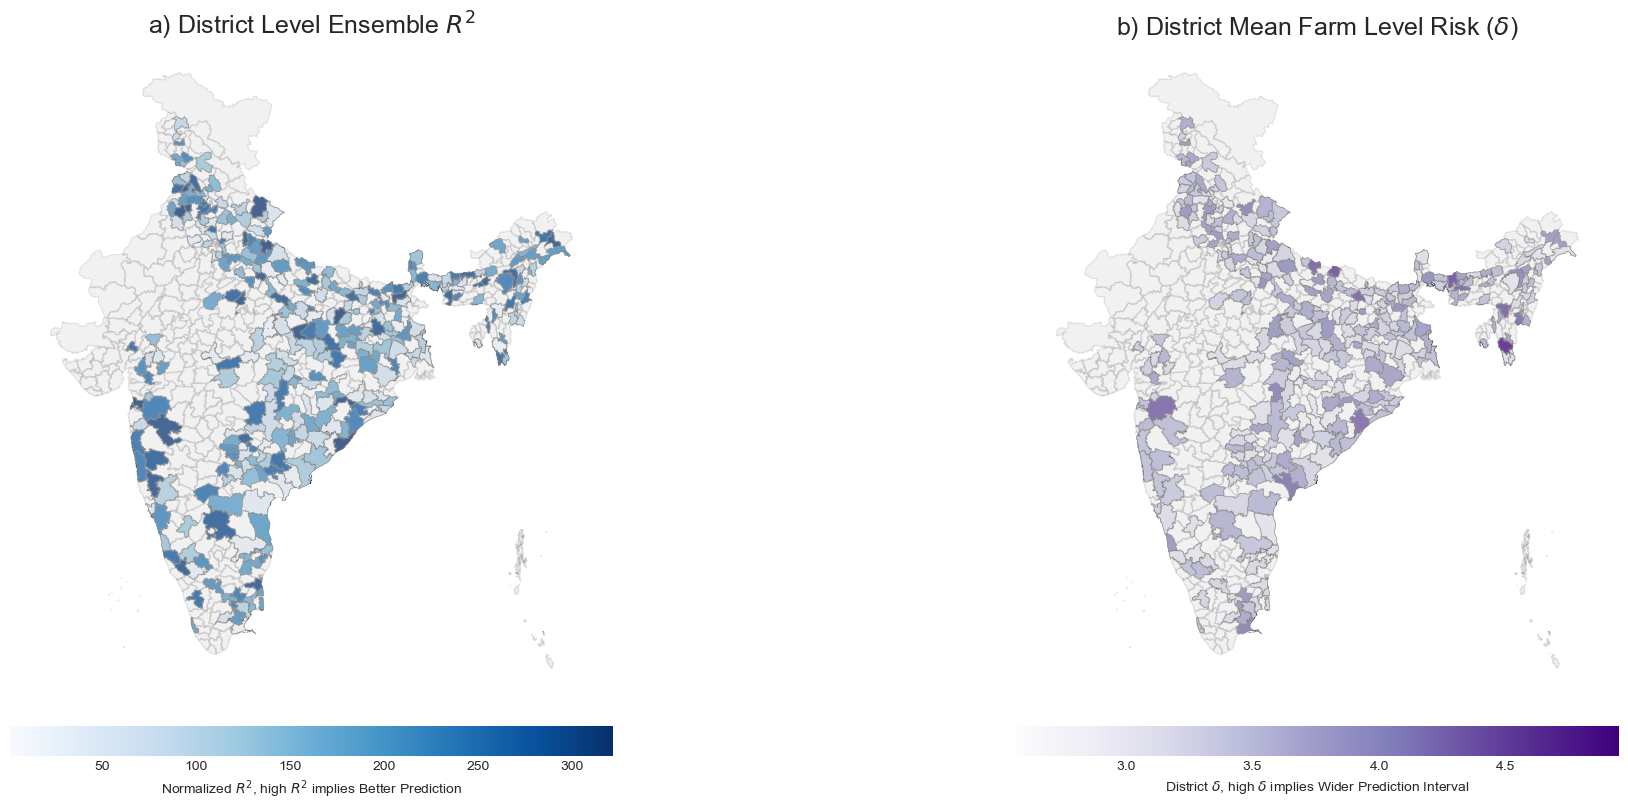

In [8]:
print('RICE MAP')
make_map_of_r2_and_risk(map_df=rice_map_data,columns=['r2_rank','pred_interval'],colors=['Blues','Purples'],
                        labels=["Normalized $R^2$, high $R^2$ implies Better Prediction ",
                                "District $\delta$, high $\delta$ implies Wider Prediction Interval "],
                        titles=["a) District Level Ensemble $R^2$","b) District Mean Farm Level Risk ($\delta$)"])

WHEAT MAP


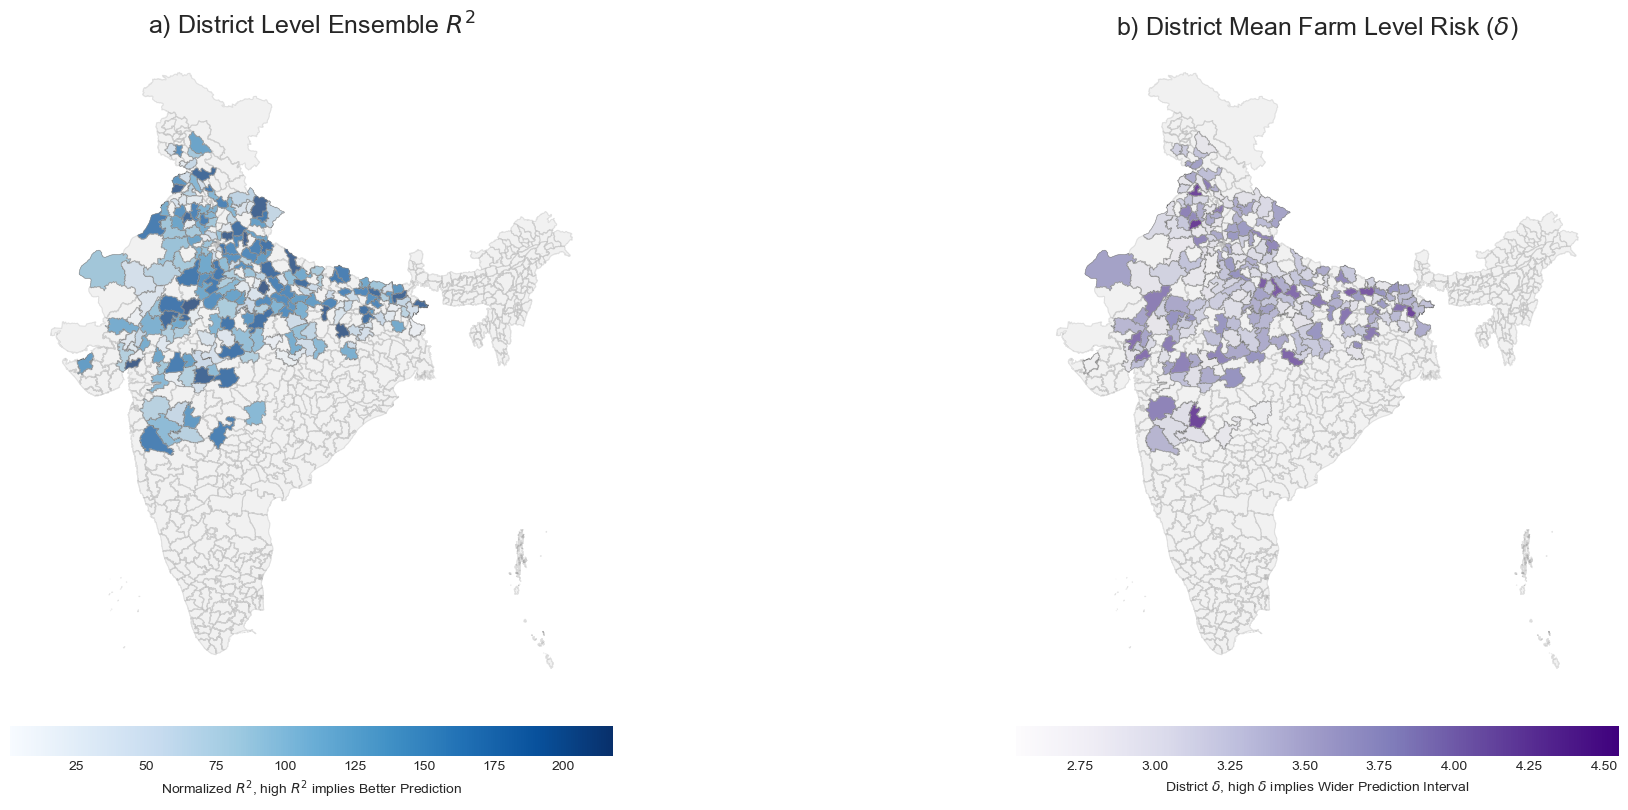

In [10]:
print('WHEAT MAP')
make_map_of_r2_and_risk(map_df=wheat_map_data,columns=['r2_rank','pred_interval'],colors=['Blues','Purples'],
                        labels=["Normalized $R^2$, high $R^2$ implies Better Prediction ",
                                "District $\delta$, high $\delta$ implies Wider Prediction Interval "],
                        titles=["a) District Level Ensemble $R^2$","b) District Mean Farm Level Risk ($\delta$)"])

In [139]:
map_district_r2=pd.merge(shpfile,r2_by_district[['spei_district_code','r2_rank']],
                         on='spei_district_code',how='inner')
print(map_district_r2.shape)

(322, 3)


In [108]:
map_district_stability=pd.merge(shpfile,district_stability,on='spei_district_code',how='outer')
print(map_district_stability.shape)
map_district_qtls=pd.merge(shpfile,district_qtls,on='spei_district_code',how='outer')
print(map_district_qtls.shape)

,spei_district_code,district_size,r2,r2_norm,r2_rank
0,11,5,-2.317546,-0.463509,318.0
1,16,37,-0.048742,-0.001317,199.0
2,17,11,-0.138213,-0.012565,229.0
3,18,26,-0.119808,-0.004608,210.0
4,25,7,-1.002074,-0.143153,294.0
...,...,...,...,...,...
317,731,8,0.235638,0.029455,89.0
318,732,17,-0.151736,-0.008926,221.0
319,734,7,-1.487745,-0.212535,307.0
320,738,5,0.002486,0.000497,188.0


## Does the mean always outperform dispersion weighting?

In [40]:
def make_low_stable_farms_dispersion(state_files_path):
    random_states=[3504,2992,3529,5042,4053,2492,9193,6843,3923,5935]
    models_list=['random-forest','svr','xgb_abs','xgb_q50','xgb_huber']
    ensemble_prediction=[]
    candidate_performances=[]
    fin_metrics=[]
    for state_space in random_states:
        print(state_space)
        infile=pd.read_csv(f'{state_files_path}preds_{state_space}.csv')
        infile=make_xid(infile.copy(),'rice')
        inr2=pd.read_csv(f'{state_files_path}r2_{state_space}.csv')
        inr2=inr2[models_list]
        kappa=2
        wts=np.exp(kappa*(inr2.sub(inr2.max(axis=1),axis=0)))
        wts_star=wts.div(wts.sum(axis=1),axis=0).mean(axis=0)
        print('The sum of normalized weights', round(wts_star.sum()))
        check_ovf=infile[['X_id','fold','rfy_pred', 'svry_pred', 'xgb_abs_pred', 'xgb_q50_pred', 'xgb_huber_pred']].copy().sort_values(by=['X_id','fold']).drop('fold',axis=1).reset_index(drop=True)
        check_ovf=check_ovf.groupby('X_id').std()
        check_ovf=pd.concat([check_ovf,
                             infile[['X_id','yeo_farm_crop_yield']].drop_duplicates().set_index('X_id')],axis=1)
        check_ovf=check_ovf.div(check_ovf.yeo_farm_crop_yield,axis=0)
        check_ovf=abs(check_ovf)
        check_ovf_qtls=pd.concat([pd.qcut(check_ovf['rfy_pred'],q=4,labels=[1,2,3,4]),
               pd.qcut(check_ovf['svry_pred'],q=4,labels=[1,2,3,4]),
               pd.qcut(check_ovf['xgb_abs_pred'],q=4,labels=[1,2,3,4]),
               pd.qcut(check_ovf['xgb_q50_pred'],q=4,labels=[1,2,3,4]),
               pd.qcut(check_ovf['xgb_huber_pred'],q=4,labels=[1,2,3,4])],axis=1)
        low_stable_farms_list=list(check_ovf_qtls[(check_ovf_qtls.min(axis=1)>=3)].index)
        low_stable_farms=infile[infile['X_id'].isin(low_stable_farms_list)].copy()
        low_stable_farms=low_stable_farms[['X_id','fold','yeo_farm_crop_yield','rfy_pred', 'svry_pred', 'xgb_abs_pred', 
                                       'xgb_q50_pred', 'xgb_huber_pred']].sort_values(by=['X_id','fold'])
        temp=make_ensemble_predictions(low_stable_farms,wts_star)
        ran=temp[0].rename(columns={'y_star':f'ran_ypred'})
        var=temp[1].rename(columns={'y_star':f'var_ypred'})
        mea=temp[2].rename(columns={'y_star':f'mea_ypred'})

        tempdf=pd.concat([ran[['y_obs',f'ran_ypred']],
                          var[[f'var_ypred']],
                          mea[[f'mea_ypred']]],
                        axis=1) ## ensemble predictions

        tempdf['state_space']=state_space
        ensemble_prediction.append(tempdf.reset_index())
        perform_dict=candidate_performance(low_stable_farms)
        perform_df=pd.DataFrame(perform_dict)
        perform_df.index=models_list ## candidate performance
        perform_df=perform_df.T
        perform_df['state_space']=state_space
        candidate_performances.append(perform_df.reset_index())
        y_obs=tempdf['y_obs'].values
        metrics_dict={'ran_r2':[r2_score(y_obs,tempdf[f'ran_ypred'])],
                      'ran_rmse':[mean_squared_error(y_obs,tempdf[f'ran_ypred'],squared=False)],
                      'ran_mae':[mean_absolute_error(y_obs,tempdf[f'ran_ypred'])],
                      'var_r2':[r2_score(y_obs,tempdf[f'var_ypred'])],
                      'var_rmse':[mean_squared_error(y_obs,tempdf[f'var_ypred'],squared=False)],
                      'var_mae':[mean_absolute_error(y_obs,tempdf[f'var_ypred'])],
                      'mea_r2':[r2_score(y_obs,tempdf[f'mea_ypred'])],
                      'mea_rmse':[mean_squared_error(y_obs,tempdf[f'mea_ypred'],squared=False)],
                      'mea_mae':[mean_absolute_error(y_obs,tempdf[f'mea_ypred'])]}
        metrics_dict['state_space']=[state_space]
        metrics_df=pd.DataFrame(metrics_dict)
        fin_metrics.append(metrics_df)
    return {'ensemble':ensemble_prediction,'candidate':candidate_performances,'metrics':fin_metrics}
def calculate_percentage_change(mean_metric,b):
    '''
    calculate the improvement of b over the mean metric
    '''
    output=((mean_metric-b)*100)/mean_metric
    return np.round(output,2)

In [12]:
state_files_path=f"{drive}/xgboost_shap/rice_ensemble_random_results/"

In [14]:
ensemble_prediction=pd.concat(ensemble_prediction,axis=0).rename(columns={'index':'X_id'})
ensemble_prediction=ensemble_prediction.sort_values(by=['state_space','X_id']).reset_index(drop=True)
ensemble_prediction

,X_id,y_obs,ran_ypred,var_ypred,mea_ypred,state_space
0,0,-0.383771,-0.91114,-0.909076,-0.943751,2492
1,1,0.58263,-0.461117,-0.45931,-0.219845,2492
2,8,-0.383771,-0.016609,-0.019832,0.217399,2492
3,9,-0.549234,-0.573444,-0.581745,-0.609591,2492
4,10,-0.501337,0.715422,0.709097,1.069503,2492
...,...,...,...,...,...,...
16950,4406,-0.651488,-0.268399,-0.261528,-0.219966,9193
16951,4408,-0.383772,-0.55843,-0.557456,-0.558828,9193
16952,4419,-0.193634,0.109365,0.111991,0.118434,9193
16953,4423,0.070398,0.245311,0.246928,0.221772,9193


In [28]:
print(f'Number of farms = {ensemble_prediction.X_id.nunique()}')

Number of farms = 2059


In [23]:
fin_metrics_df=pd.concat(fin_metrics,axis=0)
mean_metrics_df=fin_metrics_df.mean(axis=0)
fin_metrics_df=fin_metrics_df[['state_space','ran_r2', 'ran_rmse', 'ran_mae', 'var_r2', 'var_rmse', 'var_mae',
       'mea_r2', 'mea_rmse', 'mea_mae']]

In [35]:
table_dimensions=('|c'*fin_metrics_df.shape[1])+'|'
print(' \\begin{table}[ht] \n \\small \n \\centering \n \\caption{ENTER} \n \\vspace{-0.05cm}')
print('\\begin{tabular}{'+ table_dimensions + '} \n \\hline ')
col_names=fin_metrics_df.columns
table_header=col_names[0]
for col in col_names[1:]:
    table_header+= '&' + col
print(table_header+'\\')
for _, row in fin_metrics_df.iterrows():
    formatted = [f"{v:.4f}" for v in row.values]
    print(" & ".join(formatted) + r" \\")
    print(r"\hline")

 \begin{table}[ht] 
 \small 
 \centering 
 \caption{ENTER} 
 \vspace{-0.05cm}
\begin{tabular}{|c|c|c|c|c|c|c|c|c|c|} 
 \hline 
state_space&ran_r2&ran_rmse&ran_mae&var_r2&var_rmse&var_mae&mea_r2&mea_rmse&mea_mae\
3504.0000 & -0.7507 & 0.4488 & 0.3468 & -0.7529 & 0.4490 & 0.3470 & -0.8484 & 0.4611 & 0.3531 \\
\hline
2992.0000 & -0.7427 & 0.4473 & 0.3466 & -0.7405 & 0.4470 & 0.3463 & -0.8161 & 0.4566 & 0.3501 \\
\hline
3529.0000 & -0.7061 & 0.4446 & 0.3466 & -0.7094 & 0.4450 & 0.3469 & -0.7946 & 0.4560 & 0.3520 \\
\hline
5042.0000 & -0.7209 & 0.4486 & 0.3483 & -0.7206 & 0.4485 & 0.3483 & -0.8058 & 0.4595 & 0.3540 \\
\hline
4053.0000 & -0.7396 & 0.4478 & 0.3479 & -0.7387 & 0.4477 & 0.3478 & -0.8200 & 0.4580 & 0.3527 \\
\hline
2492.0000 & -0.6995 & 0.4448 & 0.3450 & -0.6978 & 0.4446 & 0.3450 & -0.7762 & 0.4547 & 0.3500 \\
\hline
9193.0000 & -0.7315 & 0.4497 & 0.3479 & -0.7301 & 0.4495 & 0.3477 & -0.8136 & 0.4602 & 0.3526 \\
\hline
6843.0000 & -0.7784 & 0.4493 & 0.3480 & -0.7781 & 0.4493 & 0

In [27]:
print('Improvement in R2-score vs std-weighting = -',calculate_percentage_change(mean_metrics_df.mea_r2,mean_metrics_df.var_r2 ),'%')
print('Improvement in R2-score vs range-weighting = -',calculate_percentage_change(mean_metrics_df.mea_r2,mean_metrics_df.ran_r2 ),'%')
print('Improvement in RMSE vs std-weighting = ',calculate_percentage_change(mean_metrics_df.mea_rmse,mean_metrics_df.var_rmse),'%')
print('Improvement in RMSE vs range-weighting = ',calculate_percentage_change(mean_metrics_df.mea_rmse,mean_metrics_df.ran_rmse ),'%')
print('Improvement in MAE vs std-weighting = ',calculate_percentage_change(mean_metrics_df.mea_mae,mean_metrics_df.var_mae ),'%')
print('Improvement in MAE vs range-weighting = ',calculate_percentage_change(mean_metrics_df.mea_mae,mean_metrics_df.ran_mae),'%')

Improvement in R2-score vs std-weighting = - 10.52 %
Improvement in R2-score vs range-weighting = - 10.47 %
Improvement in RMSE vs std-weighting =  2.41 %
Improvement in RMSE vs range-weighting =  2.4 %
Improvement in MAE vs std-weighting =  1.5 %
Improvement in MAE vs range-weighting =  1.48 %


In [41]:
state_files_path="C://Users/nb/Desktop/paper_2/xgboost_shap/wheat_ensemble_random_results/"

In [42]:
low_stable_dict=make_low_stable_farms_dispersion(state_files_path)

3504
We have unique X-row identifiers :  True
The sum of normalized weights 1
2992
We have unique X-row identifiers :  True
The sum of normalized weights 1
3529
We have unique X-row identifiers :  True
The sum of normalized weights 1
5042
We have unique X-row identifiers :  True
The sum of normalized weights 1
4053
We have unique X-row identifiers :  True
The sum of normalized weights 1
2492
We have unique X-row identifiers :  True
The sum of normalized weights 1
9193
We have unique X-row identifiers :  True
The sum of normalized weights 1
6843
We have unique X-row identifiers :  True
The sum of normalized weights 1
3923
We have unique X-row identifiers :  True
The sum of normalized weights 1
5935
We have unique X-row identifiers :  True
The sum of normalized weights 1


In [43]:
ensemble_prediction=pd.concat(low_stable_dict['ensemble'],axis=0).rename(columns={'index':'X_id'})
ensemble_prediction=ensemble_prediction.sort_values(by=['state_space','X_id']).reset_index(drop=True)
ensemble_prediction

,X_id,y_obs,ran_ypred,var_ypred,mea_ypred,state_space
0,0,-0.373737,-1.026617,-0.999387,-0.957627,2492
1,1,0.246981,1.327449,1.318487,1.936041,2492
2,3,-0.133415,0.278249,0.26964,0.348649,2492
3,8,0.534603,0.423279,0.420104,0.505859,2492
4,9,0.534603,0.127517,0.129918,0.193759,2492
...,...,...,...,...,...,...
10328,2684,-0.235251,-0.018223,-0.012045,0.037326,9193
10329,2686,-0.235251,0.425837,0.42384,0.428949,9193
10330,2687,0.363732,0.265901,0.262312,0.240393,9193
10331,2688,-0.373738,0.465633,0.462882,0.537709,9193


In [44]:
fin_metrics_df=pd.concat(low_stable_dict['metrics'],axis=0)
mean_metrics_df=fin_metrics_df.mean(axis=0)
fin_metrics_df=fin_metrics_df[['state_space','ran_r2', 'ran_rmse', 'ran_mae', 'var_r2', 'var_rmse', 'var_mae',
       'mea_r2', 'mea_rmse', 'mea_mae']]

In [45]:
table_dimensions=('|c'*fin_metrics_df.shape[1])+'|'
print(' \\begin{table}[ht] \n \\small \n \\centering \n \\caption{ENTER} \n \\vspace{-0.05cm}')
print('\\begin{tabular}{'+ table_dimensions + '} \n \\hline ')
col_names=fin_metrics_df.columns
table_header=col_names[0]
for col in col_names[1:]:
    table_header+= '&' + col
print(table_header+'\\')
for _, row in fin_metrics_df.iterrows():
    formatted = [f"{v:.4f}" for v in row.values]
    print(" & ".join(formatted) + r" \\")
    print(r"\hline")

 \begin{table}[ht] 
 \small 
 \centering 
 \caption{ENTER} 
 \vspace{-0.05cm}
\begin{tabular}{|c|c|c|c|c|c|c|c|c|c|} 
 \hline 
state_space&ran_r2&ran_rmse&ran_mae&var_r2&var_rmse&var_mae&mea_r2&mea_rmse&mea_mae\
3504.0000 & -0.7282 & 0.4009 & 0.3048 & -0.7271 & 0.4007 & 0.3045 & -0.7880 & 0.4077 & 0.3053 \\
\hline
2992.0000 & -0.7539 & 0.4053 & 0.3060 & -0.7510 & 0.4049 & 0.3060 & -0.8210 & 0.4129 & 0.3074 \\
\hline
3529.0000 & -0.7520 & 0.3944 & 0.3003 & -0.7535 & 0.3945 & 0.3003 & -0.8254 & 0.4025 & 0.3027 \\
\hline
5042.0000 & -0.7789 & 0.3898 & 0.2940 & -0.7773 & 0.3896 & 0.2941 & -0.8458 & 0.3971 & 0.2956 \\
\hline
4053.0000 & -0.7061 & 0.3946 & 0.2992 & -0.7026 & 0.3942 & 0.2989 & -0.7747 & 0.4024 & 0.3012 \\
\hline
2492.0000 & -0.6803 & 0.3951 & 0.2993 & -0.6802 & 0.3951 & 0.2995 & -0.7454 & 0.4027 & 0.3013 \\
\hline
9193.0000 & -0.7128 & 0.3950 & 0.2996 & -0.7090 & 0.3946 & 0.2994 & -0.7732 & 0.4019 & 0.3012 \\
\hline
6843.0000 & -0.8053 & 0.4043 & 0.3062 & -0.8034 & 0.4041 & 0

In [46]:
print('Improvement in R2-score vs std-weighting = -',calculate_percentage_change(mean_metrics_df.mea_r2,mean_metrics_df.var_r2 ),'%')
print('Improvement in R2-score vs range-weighting = -',calculate_percentage_change(mean_metrics_df.mea_r2,mean_metrics_df.ran_r2 ),'%')
print('Improvement in RMSE vs std-weighting = ',calculate_percentage_change(mean_metrics_df.mea_rmse,mean_metrics_df.var_rmse),'%')
print('Improvement in RMSE vs range-weighting = ',calculate_percentage_change(mean_metrics_df.mea_rmse,mean_metrics_df.ran_rmse ),'%')
print('Improvement in MAE vs std-weighting = ',calculate_percentage_change(mean_metrics_df.mea_mae,mean_metrics_df.var_mae ),'%')
print('Improvement in MAE vs range-weighting = ',calculate_percentage_change(mean_metrics_df.mea_mae,mean_metrics_df.ran_mae),'%')

Improvement in R2-score vs std-weighting = - 8.69 %
Improvement in R2-score vs range-weighting = - 8.44 %
Improvement in RMSE vs std-weighting =  1.97 %
Improvement in RMSE vs range-weighting =  1.91 %
Improvement in MAE vs std-weighting =  0.64 %
Improvement in MAE vs range-weighting =  0.6 %
